In [7]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path("/Users/hedychou/Desktop/MScDS/Research/Datasets/cdc_diabetes")

print("Files in DATA_DIR:")
for p in DATA_DIR.glob("*.csv"):
    print(p.name)

Files in DATA_DIR:
diabetes_012_health_indicators_BRFSS2015.csv
diabetes_binary_health_indicators_BRFSS2015.csv
diabetes_binary_5050split_health_indicators_BRFSS2015.csv


In [9]:
candidate_files = [
    "diabetes_binary_health_indicators_BRFSS2015.csv",
    "diabetes_binary_5050split_health_indicators_BRFSS2015.csv",
    "diabetes_012_health_indicators_BRFSS2015.csv",
]

csv_path = None
for fname in candidate_files:
    p = DATA_DIR / fname
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    csv_files = list(DATA_DIR.glob("*.csv"))
    if len(csv_files) == 0:
        raise FileNotFoundError("No CSV file found in DATA_DIR.")
    csv_path = csv_files[0]

print("Using CSV:", csv_path)

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print(df.columns.tolist())
df.head()

Using CSV: /Users/hedychou/Desktop/MScDS/Research/Datasets/cdc_diabetes/diabetes_binary_health_indicators_BRFSS2015.csv
Shape: (253680, 22)
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [10]:
# Build binary label

if "Diabetes_binary" in df.columns:
    target_col = "Diabetes_binary"
    df["label"] = df[target_col].astype(int)

elif "Diabetes_012" in df.columns:
    target_col = "Diabetes_012"
    # 0 = no diabetes, 1 = prediabetes, 2 = diabetes
    # 这里做 diabetes vs non-diabetes
    df["label"] = (df[target_col] == 2).astype(int)

else:
    raise ValueError("Cannot find Diabetes_binary or Diabetes_012 target column.")

print("Target column:", target_col)
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))

Target column: Diabetes_binary
label
0    218334
1     35346
Name: count, dtype: int64
label
0    0.860667
1    0.139333
Name: proportion, dtype: float64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

drop_cols = ["label"]

if "Diabetes_binary" in df.columns:
    drop_cols.append("Diabetes_binary")

if "Diabetes_012" in df.columns:
    drop_cols.append("Diabetes_012")

X_df = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df["label"].values.astype(np.int64)

# 确保全是数值
X_df = X_df.apply(pd.to_numeric, errors="coerce")
X_df = X_df.fillna(X_df.median(numeric_only=True))

print("Feature shape before scaling:", X_df.shape)
print("Label positive rate:", y.mean())

scaler = StandardScaler()
X = scaler.fit_transform(X_df).astype(np.float32)

print("Processed X shape:", X.shape)
print("y shape:", y.shape)

Feature shape before scaling: (253680, 21)
Label positive rate: 0.13933301797540207
Processed X shape: (253680, 21)
y shape: (253680,)


In [12]:
# Global train / val / test split

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.15,
    random_state=SEED + 1,
    stratify=y_trainval
)

print("Train:", X_train.shape, "pos_rate:", y_train.mean())
print("Val:", X_val.shape, "pos_rate:", y_val.mean())
print("Test:", X_test.shape, "pos_rate:", y_test.mean())

input_dim = X_train.shape[1]
NUM_CLASSES = 2

print("input_dim:", input_dim)

Train: (183283, 21) pos_rate: 0.13933097995995264
Val: (32345, 21) pos_rate: 0.13934147472561448
Test: (38052, 21) pos_rate: 0.1393356459581625
input_dim: 21


In [13]:
def dirichlet_split_indices(y, num_clients=10, alpha=0.5, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y)

    classes = np.unique(y)
    client_indices = [[] for _ in range(num_clients)]

    for c in classes:
        idx_c = np.where(y == c)[0]
        rng.shuffle(idx_c)

        proportions = rng.dirichlet(alpha * np.ones(num_clients))
        split_points = (np.cumsum(proportions) * len(idx_c)).astype(int)[:-1]
        splits = np.split(idx_c, split_points)

        for cid, split in enumerate(splits):
            client_indices[cid].extend(split.tolist())

    for cid in range(num_clients):
        rng.shuffle(client_indices[cid])

    return [np.array(idx, dtype=int) for idx in client_indices]


NUM_CLIENTS = 15

client_train_indices = dirichlet_split_indices(
    y_train,
    num_clients=NUM_CLIENTS,
    alpha=0.5,
    seed=SEED
)

for cid, idx in enumerate(client_train_indices):
    yy = y_train[idx]
    print(
        f"Client {cid}: n={len(idx)}, "
        f"pos={int((yy == 1).sum())}, "
        f"neg={int((yy == 0).sum())}, "
        f"pos_rate={yy.mean():.4f}"
    )

Client 0: n=27929, pos=6883, neg=21046, pos_rate=0.2464
Client 1: n=17075, pos=1432, neg=15643, pos_rate=0.0839
Client 2: n=58, pos=10, neg=48, pos_rate=0.1724
Client 3: n=2568, pos=107, neg=2461, pos_rate=0.0417
Client 4: n=20223, pos=354, neg=19869, pos_rate=0.0175
Client 5: n=947, pos=946, neg=1, pos_rate=0.9989
Client 6: n=24661, pos=13668, neg=10993, pos_rate=0.5542
Client 7: n=41797, pos=377, neg=41420, pos_rate=0.0090
Client 8: n=236, pos=194, neg=42, pos_rate=0.8220
Client 9: n=2444, pos=2, neg=2442, pos_rate=0.0008
Client 10: n=36082, pos=313, neg=35769, pos_rate=0.0087
Client 11: n=2409, pos=224, neg=2185, pos_rate=0.0930
Client 12: n=2236, pos=364, neg=1872, pos_rate=0.1628
Client 13: n=4516, pos=572, neg=3944, pos_rate=0.1267
Client 14: n=102, pos=91, neg=11, pos_rate=0.8922


In [14]:
def split_client_train_val_indices(
    y_train,
    client_train_indices,
    val_ratio=0.2,
    seed=42,
):
    client_train_split_indices = []
    client_val_split_indices = []

    rng = np.random.default_rng(seed)

    for cid, idx in enumerate(client_train_indices):
        idx = np.array(idx)
        y_c = y_train[idx]

        if len(np.unique(y_c)) == 2 and min(np.bincount(y_c, minlength=2)) >= 2:
            train_idx_c, val_idx_c = train_test_split(
                idx,
                test_size=val_ratio,
                random_state=seed + cid,
                stratify=y_c
            )
        else:
            rng.shuffle(idx)
            cut = max(1, int(len(idx) * (1 - val_ratio)))
            train_idx_c = idx[:cut]
            val_idx_c = idx[cut:]

        client_train_split_indices.append(np.array(train_idx_c))
        client_val_split_indices.append(np.array(val_idx_c))

    return client_train_split_indices, client_val_split_indices


client_train_split_indices, client_val_split_indices = split_client_train_val_indices(
    y_train=y_train,
    client_train_indices=client_train_indices,
    val_ratio=0.2,
    seed=SEED
)

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader

class EHRTabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 128
NUM_WORKERS = 0

client_loaders = []
client_val_loaders = []

for cid in range(NUM_CLIENTS):
    train_idx_c = client_train_split_indices[cid]
    val_idx_c = client_val_split_indices[cid]

    train_ds = EHRTabularDataset(X_train[train_idx_c], y_train[train_idx_c])
    val_ds = EHRTabularDataset(X_train[val_idx_c], y_train[val_idx_c])

    client_loaders.append(
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    )

    client_val_loaders.append(
        DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    )

global_val_loader = DataLoader(
    EHRTabularDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

global_test_loader = DataLoader(
    EHRTabularDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("client_loaders:", len(client_loaders))
print("client_val_loaders:", len(client_val_loaders))

client_loaders: 15
client_val_loaders: 15


In [16]:
def collect_loader_labels(loader):
    ys = []
    for _, yb in loader:
        ys.extend(yb.cpu().numpy().tolist())
    return np.array(ys)


def summarize_client_label_distribution(client_loaders, client_val_loaders):
    rows = []

    for cid in range(len(client_loaders)):
        y_tr = collect_loader_labels(client_loaders[cid])
        y_va = collect_loader_labels(client_val_loaders[cid])

        rows.append({
            "client_id": cid,
            "train_n": len(y_tr),
            "train_pos": int((y_tr == 1).sum()),
            "train_neg": int((y_tr == 0).sum()),
            "train_pos_rate": float(y_tr.mean()),
            "val_n": len(y_va),
            "val_pos": int((y_va == 1).sum()),
            "val_neg": int((y_va == 0).sum()),
            "val_pos_rate": float(y_va.mean()),
            "flag_single_label_train": len(np.unique(y_tr)) < 2,
            "flag_single_label_val": len(np.unique(y_va)) < 2,
        })

    return pd.DataFrame(rows)


cdc_client_summary_df = summarize_client_label_distribution(
    client_loaders,
    client_val_loaders
)

cdc_client_summary_df

,client_id,train_n,train_pos,train_neg,train_pos_rate,val_n,val_pos,val_neg,val_pos_rate,flag_single_label_train,flag_single_label_val
0,0,22343,5506,16837,0.246431,5586,1377,4209,0.246509,False,False
1,1,13660,1146,12514,0.083895,3415,286,3129,0.083748,False,False
2,2,46,8,38,0.173913,12,2,10,0.166667,False,False
3,3,2054,86,1968,0.041870,514,21,493,0.040856,False,False
4,4,16178,283,15895,0.017493,4045,71,3974,0.017553,False,False
5,5,757,756,1,0.998679,190,190,0,1.000000,False,True
6,6,19728,10934,8794,0.554238,4933,2734,2199,0.554227,False,False
7,7,33437,302,33135,0.009032,8360,75,8285,0.008971,False,False
8,8,188,155,33,0.824468,48,39,9,0.812500,False,False
9,9,1955,2,1953,0.001023,489,0,489,0.000000,False,True


In [17]:
MIN_TRAIN_N = 100
MIN_VAL_N = 30
MIN_POS_TRAIN = 5
MIN_POS_VAL = 2

good_clients = []

for _, row in cdc_client_summary_df.iterrows():
    ok = True
    ok = ok and row["train_n"] >= MIN_TRAIN_N
    ok = ok and row["val_n"] >= MIN_VAL_N
    ok = ok and row["train_pos"] >= MIN_POS_TRAIN
    ok = ok and row["val_pos"] >= MIN_POS_VAL
    ok = ok and not row["flag_single_label_train"]
    ok = ok and not row["flag_single_label_val"]

    if ok:
        good_clients.append(int(row["client_id"]))

print("Good clients:", good_clients)
print("Number of good clients:", len(good_clients))

client_loaders_good = [client_loaders[cid] for cid in good_clients]
client_val_loaders_good = [client_val_loaders[cid] for cid in good_clients]

print("Filtered train loaders:", len(client_loaders_good))

Good clients: [0, 1, 3, 4, 6, 7, 8, 10, 11, 12, 13]
Number of good clients: 11
Filtered train loaders: 11


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_labels_all = []

for loader in client_loaders_good:
    for _, yb in loader:
        train_labels_all.extend(yb.cpu().numpy().tolist())

train_labels_all = np.array(train_labels_all)
class_counts = np.bincount(train_labels_all, minlength=2)

print("Class counts:", class_counts)
print("Positive rate:", class_counts[1] / class_counts.sum())

class_weights_np = class_counts.sum() / (2 * np.maximum(class_counts, 1))
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("class_weights:", class_weights)

Using device: cpu
Class counts: [124191  19589]
Positive rate: 0.13624287105299762
class_weights: tensor([0.5789, 3.6699])


In [19]:
import torch.nn as nn
import torch.nn.functional as F

EHR_INPUT_DIM = input_dim
NUM_CLASSES = 2

def _as_tabular_input(x):
    if x.dim() > 2:
        x = x.view(x.size(0), -1)
    return x.float()


class TeacherECG1D(nn.Module):
    """
    CDC EHR Teacher MLP.
    Keep old class name for compatibility with existing Stage 1 code.
    """
    def __init__(
        self,
        num_classes=2,
        input_dim=None,
        hidden_dim=256,
        feat_dim=128,
        dropout=0.20,
        **kwargs
    ):
        super().__init__()

        if input_dim is None:
            input_dim = EHR_INPUT_DIM

        self.features = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, feat_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.fc = nn.Linear(feat_dim, feat_dim)
        self.out = nn.Linear(feat_dim, num_classes)

    def forward(self, x, return_feat=False):
        x = _as_tabular_input(x)
        h = self.features(x)
        feat = F.relu(self.fc(h))
        logits = self.out(feat)

        if return_feat:
            return logits, feat
        return logits


class StudentBackboneECG1D(nn.Module):
    """
    CDC EHR Student shared backbone.
    """
    def __init__(self, input_dim=None, hidden_dim=64, **kwargs):
        super().__init__()

        if input_dim is None:
            input_dim = EHR_INPUT_DIM

        self.out_dim = hidden_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        x = _as_tabular_input(x)
        return self.net(x)


class StudentHead(nn.Module):
    def __init__(self, in_dim=64, num_classes=2):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)

    def forward(self, feat):
        return self.fc(feat)


class StudentModelECG1D(nn.Module):
    def __init__(self, num_classes=2, input_dim=None, hidden_dim=64, **kwargs):
        super().__init__()

        if input_dim is None:
            input_dim = EHR_INPUT_DIM

        self.backbone = StudentBackboneECG1D(
            input_dim=input_dim,
            hidden_dim=hidden_dim
        )

        self.head = StudentHead(
            in_dim=hidden_dim,
            num_classes=num_classes
        )

    def forward(self, x, return_feat=False):
        feat = self.backbone(x)
        logits = self.head(feat)

        if return_feat:
            return logits, feat
        return logits


class TeacherFeatProjector(nn.Module):
    def __init__(self, in_dim=128, out_dim=64):
        super().__init__()
        self.proj = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        return self.proj(x)

print("CDC EHR MLP models ready.")

CDC EHR MLP models ready.


In [20]:
xb, yb = next(iter(client_loaders_good[0]))
xb = xb.to(device)

teacher_tmp = TeacherECG1D(num_classes=2).to(device)
student_tmp = StudentModelECG1D(num_classes=2).to(device)
projector_tmp = TeacherFeatProjector(in_dim=128, out_dim=64).to(device)

with torch.no_grad():
    t_logits, t_feat = teacher_tmp(xb, return_feat=True)
    s_logits, s_feat = student_tmp(xb, return_feat=True)
    t_proj = projector_tmp(t_feat)

print("Input:", xb.shape)
print("Teacher logits:", t_logits.shape)
print("Teacher feat:", t_feat.shape)
print("Student logits:", s_logits.shape)
print("Student feat:", s_feat.shape)
print("Projected teacher feat:", t_proj.shape)

Input: torch.Size([128, 21])
Teacher logits: torch.Size([128, 2])
Teacher feat: torch.Size([128, 128])
Student logits: torch.Size([128, 2])
Student feat: torch.Size([128, 64])
Projected teacher feat: torch.Size([128, 64])


In [21]:
REAL_ANCHOR_PER_CLASS = 1000

rng = np.random.default_rng(SEED)

pos_indices = np.where(y_train == 1)[0]
neg_indices = np.where(y_train == 0)[0]

n_pos_anchor = min(REAL_ANCHOR_PER_CLASS, len(pos_indices))
n_neg_anchor = min(REAL_ANCHOR_PER_CLASS, len(neg_indices))

pos_anchor_indices = rng.choice(pos_indices, size=n_pos_anchor, replace=False)
neg_anchor_indices = rng.choice(neg_indices, size=n_neg_anchor, replace=False)

anchor_indices = np.concatenate([pos_anchor_indices, neg_anchor_indices])
rng.shuffle(anchor_indices)

X_anchor = X_train[anchor_indices]
y_anchor = y_train[anchor_indices]

anchor_loader = DataLoader(
    EHRTabularDataset(X_anchor, y_anchor),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Anchor size:", len(y_anchor))
print(pd.Series(y_anchor).value_counts().sort_index())
print(pd.Series(y_anchor).value_counts(normalize=True).sort_index())

Anchor size: 2000
0    1000
1    1000
Name: count, dtype: int64
0    0.5
1    0.5
Name: proportion, dtype: float64


In [22]:
# Stage 1 Core Functions: Metrics

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    average_precision_score,
    confusion_matrix,
)


@torch.no_grad()
def eval_model_binary(model, loader, device, threshold=0.5):
    model.eval()

    y_true = []
    y_prob = []
    losses = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = F.cross_entropy(logits, yb)

        prob = torch.softmax(logits, dim=1)[:, 1]

        losses.append(loss.item() * yb.size(0))
        y_true.extend(yb.detach().cpu().numpy().tolist())
        y_prob.extend(prob.detach().cpu().numpy().tolist())

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    if len(y_true) == 0:
        raise ValueError("Empty loader received in eval_model_binary.")

    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred) * 100
    bal_acc = balanced_accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, zero_division=0) * 100
    recall = recall_score(y_true, y_pred, zero_division=0) * 100
    precision = precision_score(y_true, y_pred, zero_division=0) * 100

    try:
        auprc = average_precision_score(y_true, y_prob) * 100
    except Exception:
        auprc = float(np.mean(y_true)) * 100

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / max(tn + fp, 1) * 100

    total_n = len(y_true)
    avg_loss = np.sum(losses) / max(total_n, 1)

    return {
        "loss": float(avg_loss),
        "acc": float(acc),
        "bal_acc": float(bal_acc),
        "f1": float(f1),
        "recall": float(recall),
        "precision": float(precision),
        "specificity": float(specificity),
        "auprc": float(auprc),
        "pred_pos_rate": float(np.mean(y_pred) * 100),
        "true_pos_rate": float(np.mean(y_true) * 100),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

In [23]:
# Personal head evaluation

@torch.no_grad()
def eval_personal_heads_binary(student, personal_heads, client_val_loaders, device, threshold=0.5):
    student.eval()
    for head in personal_heads:
        head.eval()

    y_true_all = []
    y_prob_all = []
    losses = []

    for cid, loader in enumerate(client_val_loaders):
        head = personal_heads[cid]

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            feat = student.backbone(xb)
            logits = head(feat)

            loss = F.cross_entropy(logits, yb)
            prob = torch.softmax(logits, dim=1)[:, 1]

            losses.append(loss.item() * yb.size(0))
            y_true_all.extend(yb.detach().cpu().numpy().tolist())
            y_prob_all.extend(prob.detach().cpu().numpy().tolist())

    y_true = np.asarray(y_true_all)
    y_prob = np.asarray(y_prob_all)

    if len(y_true) == 0:
        raise ValueError("Empty validation data in eval_personal_heads_binary.")

    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred) * 100
    bal_acc = balanced_accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, zero_division=0) * 100
    recall = recall_score(y_true, y_pred, zero_division=0) * 100

    try:
        auprc = average_precision_score(y_true, y_prob) * 100
    except Exception:
        auprc = float(np.mean(y_true)) * 100

    avg_loss = np.sum(losses) / max(len(y_true), 1)

    return {
        "loss": float(avg_loss),
        "acc": float(acc),
        "bal_acc": float(bal_acc),
        "f1": float(f1),
        "recall": float(recall),
        "auprc": float(auprc),
    }

In [24]:
def train_teacher_strong(
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-3,
    patience=5,
    min_epochs=5,
    class_weights=None,
    grad_clip=5.0,
    use_scheduler=True,
    log_gradients=True,
    log_every_epoch=True,
    disable_early_stop=True,
):
    model = TeacherECG1D(num_classes=NUM_CLASSES).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2
        )
    else:
        scheduler = None

    if class_weights is not None:
        ce_weight = class_weights.to(device)
    else:
        ce_weight = None

    best_score = -np.inf
    best_state = None
    best_epoch = None
    wait = 0
    grad_history = []

    for ep in range(1, epochs + 1):
        model.train()

        total_loss = 0.0
        total_n = 0

        grad_norms_pre = []
        grad_norms_post = []
        mean_abs_grads = []
        max_abs_grads = []
        zero_fracs = []
        clip_hits = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)
            loss = F.cross_entropy(logits, yb, weight=ce_weight)

            loss.backward()

            # Gradient diagnostics before clipping
            if log_gradients:
                all_grads = []
                for p in model.parameters():
                    if p.grad is not None:
                        all_grads.append(p.grad.detach().flatten())

                if len(all_grads) > 0:
                    g = torch.cat(all_grads)
                    grad_norm_pre = torch.norm(g).item()
                    mean_abs_grad = torch.mean(torch.abs(g)).item()
                    max_abs_grad = torch.max(torch.abs(g)).item()
                    zero_frac = torch.mean((g == 0).float()).item()
                else:
                    grad_norm_pre = 0.0
                    mean_abs_grad = 0.0
                    max_abs_grad = 0.0
                    zero_frac = 1.0

                grad_norms_pre.append(grad_norm_pre)
                mean_abs_grads.append(mean_abs_grad)
                max_abs_grads.append(max_abs_grad)
                zero_fracs.append(zero_frac)

            if grad_clip is not None:
                grad_norm_post = torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=grad_clip
                )
                grad_norm_post = float(min(grad_norm_post, grad_clip))
            else:
                grad_norm_post = grad_norm_pre if log_gradients else 0.0

            if log_gradients:
                grad_norms_post.append(grad_norm_post)
                clip_hits.append(float(grad_norm_pre > grad_clip) if grad_clip is not None else 0.0)

            optimizer.step()

            total_loss += loss.item() * yb.size(0)
            total_n += yb.size(0)

        train_loss = total_loss / max(total_n, 1)

        val_metrics = eval_model_binary(
            model=model,
            loader=val_loader,
            device=device,
            threshold=0.5
        )

        # Stable original teacher score
        score = 0.7 * val_metrics["bal_acc"] + 0.3 * val_metrics["auprc"]

        if scheduler is not None:
            scheduler.step(score)

        # Save best teacher checkpoint
        if score > best_score:
            best_score = score
            best_epoch = ep
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

        grad_item = {
            "epoch": ep,
            "train_loss": float(train_loss),
            "val_loss": float(val_metrics["loss"]),
            "val_acc": float(val_metrics["acc"]),
            "val_bal_acc": float(val_metrics["bal_acc"]),
            "val_auprc": float(val_metrics["auprc"]),
            "score": float(score),
            "lr": float(optimizer.param_groups[0]["lr"]),
            "grad_norm_mean_preclip": float(np.mean(grad_norms_pre)) if len(grad_norms_pre) > 0 else 0.0,
            "grad_norm_mean_postclip": float(np.mean(grad_norms_post)) if len(grad_norms_post) > 0 else 0.0,
            "mean_abs_grad_mean": float(np.mean(mean_abs_grads)) if len(mean_abs_grads) > 0 else 0.0,
            "max_abs_grad_max": float(np.max(max_abs_grads)) if len(max_abs_grads) > 0 else 0.0,
            "zero_frac_mean": float(np.mean(zero_fracs)) if len(zero_fracs) > 0 else 0.0,
            "clip_hit_frac": float(np.mean(clip_hits)) if len(clip_hits) > 0 else 0.0,
        }

        grad_history.append(grad_item)

        if log_every_epoch:
            print(
                f"[Teacher] Epoch {ep}/{epochs} | "
                f"TrainLoss={train_loss:.4f} | "
                f"ValLoss={val_metrics['loss']:.4f} | "
                f"ValAcc={val_metrics['acc']:.2f}% | "
                f"ValBalAcc={val_metrics['bal_acc']:.2f}% | "
                f"ValAUPRC={val_metrics['auprc']:.2f}% | "
                f"Score={score:.2f} | "
                f"LR={optimizer.param_groups[0]['lr']:.2e}"
            )

        if (not disable_early_stop) and ep >= min_epochs and wait >= patience:
            print("[Teacher] Early stop.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.grad_history = grad_history
    model.best_score = best_score
    model.best_epoch = best_epoch

    print(f"[Teacher] Restore best epoch {best_epoch} with best_score={best_score:.2f}")

    return model

In [25]:
def stage1_train_aligned(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    test_loader,

    num_rounds=20,
    teacher_epochs=15,
    teacher_patience=5,
    teacher_min_epochs=5,
    teacher_disable_early_stop=True,

    lr_teacher=1e-3,
    lr_student=8e-4,
    head_epochs=2,
    head_lr=1e-3,
    anchor_epochs_per_round=1,

    lambda_kd=1.0,
    lambda_feat=0.05,
    lambda_pseudo_max=0.30,
    pseudo_start_round=5,
    conf_ce_thresh=0.80,
    clip_norm=10.0,
    noise_std=0.0,
    class_weights=None,

    run_name="CDC-ALIGN-FILTERED-CLIENTS",
):
    if "anchor_loader" not in globals():
        raise ValueError("anchor_loader is not defined. Please build anchor_loader before Stage 1.")

    print(f"[{run_name}] Training teachers...")

    teachers = []

    for cid in range(len(client_loaders)):
        print(f"[{run_name}] Teacher {cid}...")

        teacher = train_teacher_strong(
            train_loader=client_loaders[cid],
            val_loader=client_val_loaders[cid],
            epochs=teacher_epochs,
            lr=lr_teacher,
            patience=teacher_patience,
            min_epochs=teacher_min_epochs,
            class_weights=class_weights,
            grad_clip=clip_norm,
            use_scheduler=True,
            log_gradients=True,
            log_every_epoch=True,
            disable_early_stop=teacher_disable_early_stop,
        )

        teacher.eval()
        teachers.append(teacher)

    print(f"[{run_name}] Teacher training completed. Num teachers = {len(teachers)}")

    # Student + projector
    student = StudentModelECG1D(num_classes=NUM_CLASSES).to(device)
    projector = TeacherFeatProjector(in_dim=128, out_dim=64).to(device)

    optimizer_student = torch.optim.AdamW(
        list(student.parameters()) + list(projector.parameters()),
        lr=lr_student,
        weight_decay=1e-4
    )

    if class_weights is not None:
        ce_weight = class_weights.to(device)
    else:
        ce_weight = None

    # Personalized heads
    personal_heads = []
    for _ in range(len(client_loaders)):
        head = StudentHead(in_dim=64, num_classes=NUM_CLASSES).to(device)
        personal_heads.append(head)

    history = {
        "round": [],
        "anchor_loss": [],
        "anchor_kd_loss": [],
        "anchor_feat_loss": [],
        "anchor_pseudo_loss": [],
        "head_loss": [],
        "val_acc": [],
        "val_bal_acc": [],
        "val_f1": [],
        "val_auprc": [],
        "personal_acc": [],
        "personal_bal_acc": [],
        "personal_f1": [],
    }

    best_score = -np.inf
    best_student_sd = None
    best_projector_sd = None
    best_personal_heads = None
    best_round = None

    temperature = 2.0

    for rnd in range(1, num_rounds + 1):
        print(f"\n[{run_name}] Round {rnd}/{num_rounds}")

        student.train()
        projector.train()

        round_anchor_loss = []
        round_kd_loss = []
        round_feat_loss = []
        round_pseudo_loss = []

        if rnd < pseudo_start_round:
            lambda_pseudo = 0.0
        else:
            lambda_pseudo = lambda_pseudo_max

        for _ in range(anchor_epochs_per_round):
            for xb, yb in anchor_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                optimizer_student.zero_grad()

                s_logits, s_feat = student(xb, return_feat=True)

                teacher_probs_list = []
                teacher_feat_list = []

                with torch.no_grad():
                    for teacher in teachers:
                        t_logits, t_feat = teacher(xb, return_feat=True)
                        t_prob = torch.softmax(t_logits / temperature, dim=1)

                        teacher_probs_list.append(t_prob)
                        teacher_feat_list.append(t_feat)

                    mean_teacher_prob = torch.stack(teacher_probs_list, dim=0).mean(dim=0)
                    mean_teacher_feat = torch.stack(teacher_feat_list, dim=0).mean(dim=0)

                # KD loss
                kd_loss = F.kl_div(
                    F.log_softmax(s_logits / temperature, dim=1),
                    mean_teacher_prob,
                    reduction="batchmean"
                ) * (temperature ** 2)

                # Feature alignment loss
                projected_teacher_feat = projector(mean_teacher_feat)
                feat_loss = F.mse_loss(s_feat, projected_teacher_feat)

                # Pseudo-label CE loss
                with torch.no_grad():
                    conf, pseudo_y = torch.max(mean_teacher_prob, dim=1)
                    mask = conf >= conf_ce_thresh

                if mask.sum() > 0 and lambda_pseudo > 0:
                    pseudo_loss = F.cross_entropy(
                        s_logits[mask],
                        pseudo_y[mask],
                        weight=ce_weight
                    )
                else:
                    pseudo_loss = torch.tensor(0.0, device=device)

                loss = (
                    lambda_kd * kd_loss
                    + lambda_feat * feat_loss
                    + lambda_pseudo * pseudo_loss
                )

                if noise_std > 0:
                    noise = torch.randn_like(loss) * noise_std
                    loss = loss + noise

                loss.backward()

                if clip_norm is not None:
                    torch.nn.utils.clip_grad_norm_(
                        list(student.parameters()) + list(projector.parameters()),
                        max_norm=clip_norm
                    )

                optimizer_student.step()

                round_anchor_loss.append(loss.item())
                round_kd_loss.append(kd_loss.item())
                round_feat_loss.append(feat_loss.item())
                round_pseudo_loss.append(pseudo_loss.item())

        # Train personalized heads
        student.eval()
        head_losses = []

        for cid, loader in enumerate(client_loaders):
            head = personal_heads[cid]
            head.train()

            optimizer_head = torch.optim.AdamW(
                head.parameters(),
                lr=head_lr,
                weight_decay=1e-4
            )

            for _ in range(head_epochs):
                for xb, yb in loader:
                    xb = xb.to(device)
                    yb = yb.to(device)

                    optimizer_head.zero_grad()

                    with torch.no_grad():
                        feat = student.backbone(xb)

                    logits = head(feat)
                    head_loss = F.cross_entropy(logits, yb, weight=ce_weight)

                    head_loss.backward()
                    optimizer_head.step()

                    head_losses.append(head_loss.item())

        # Evaluation
        val_metrics = eval_model_binary(
            model=student,
            loader=global_val_loader,
            device=device,
            threshold=0.5
        )

        personal_metrics = eval_personal_heads_binary(
            student=student,
            personal_heads=personal_heads,
            client_val_loaders=client_val_loaders,
            device=device,
            threshold=0.5
        )

        anchor_loss_mean = float(np.mean(round_anchor_loss)) if len(round_anchor_loss) > 0 else np.nan
        kd_loss_mean = float(np.mean(round_kd_loss)) if len(round_kd_loss) > 0 else np.nan
        feat_loss_mean = float(np.mean(round_feat_loss)) if len(round_feat_loss) > 0 else np.nan
        pseudo_loss_mean = float(np.mean(round_pseudo_loss)) if len(round_pseudo_loss) > 0 else np.nan
        head_loss_mean = float(np.mean(head_losses)) if len(head_losses) > 0 else np.nan

        history["round"].append(rnd)
        history["anchor_loss"].append(anchor_loss_mean)
        history["anchor_kd_loss"].append(kd_loss_mean)
        history["anchor_feat_loss"].append(feat_loss_mean)
        history["anchor_pseudo_loss"].append(pseudo_loss_mean)
        history["head_loss"].append(head_loss_mean)
        history["val_acc"].append(val_metrics["acc"])
        history["val_bal_acc"].append(val_metrics["bal_acc"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_auprc"].append(val_metrics["auprc"])
        history["personal_acc"].append(personal_metrics["acc"])
        history["personal_bal_acc"].append(personal_metrics["bal_acc"])
        history["personal_f1"].append(personal_metrics["f1"])

        print(
            f"[{run_name}][Round {rnd}/{num_rounds}] "
            f"AnchorLoss={anchor_loss_mean:.4f} | "
            f"KD={kd_loss_mean:.4f} | "
            f"Feat={feat_loss_mean:.4f} | "
            f"Pseudo={pseudo_loss_mean:.4f} | "
            f"HeadLoss={head_loss_mean:.4f} | "
            f"ValAcc={val_metrics['acc']:.2f}% | "
            f"ValBalAcc={val_metrics['bal_acc']:.2f}% | "
            f"ValF1={val_metrics['f1']:.2f}% | "
            f"ValAUPRC={val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={personal_metrics['acc']:.2f}% | "
            f"PersonalBalAcc={personal_metrics['bal_acc']:.2f}% | "
            f"PersonalF1={personal_metrics['f1']:.2f}%"
        )

        # Best selection: global + personalized balanced objective
        round_score = (
            0.45 * val_metrics["bal_acc"]
            + 0.25 * val_metrics["auprc"]
            + 0.20 * personal_metrics["bal_acc"]
            + 0.10 * personal_metrics["f1"]
        )

        if round_score > best_score:
            best_score = round_score
            best_round = rnd
            best_student_sd = {
                k: v.detach().cpu().clone()
                for k, v in student.state_dict().items()
            }
            best_projector_sd = {
                k: v.detach().cpu().clone()
                for k, v in projector.state_dict().items()
            }
            best_personal_heads = [
                {
                    k: v.detach().cpu().clone()
                    for k, v in head.state_dict().items()
                }
                for head in personal_heads
            ]

    # Restore best student state
    if best_student_sd is not None:
        student.load_state_dict(best_student_sd)

    if best_projector_sd is not None:
        projector.load_state_dict(best_projector_sd)

    if best_personal_heads is not None:
        for head, sd in zip(personal_heads, best_personal_heads):
            head.load_state_dict(sd)

    final_test_metrics = eval_model_binary(
        model=student,
        loader=test_loader,
        device=device,
        threshold=0.5
    )

    print("\n" + "=" * 80)
    print(f"[{run_name}] Stage 1 completed.")
    print(f"Best round: {best_round} | Best score: {best_score:.4f}")
    print("Final test metrics:")
    for k, v in final_test_metrics.items():
        if isinstance(v, (int, float)):
            print(f"{k}: {v:.4f}")
        else:
            print(k, v)
    print("=" * 80)

    result = {
        "teachers": teachers,
        "student_model": student,
        "projector": projector,
        "personal_heads": personal_heads,

        "best_round": best_round,
        "best_score": best_score,

        "best_student_sd": best_student_sd,
        "best_shared_sd": {
            k: v.detach().cpu().clone()
            for k, v in student.backbone.state_dict().items()
        },
        "best_projector_sd": best_projector_sd,
        "best_personal_heads": best_personal_heads,

        "history": history,
        "final_test_metrics": final_test_metrics,
        "run_name": run_name,
    }

    return result

In [26]:
import os

for root, dirs, files in os.walk("."):
    for f in files:
        if "CDC" in f.upper() and "STAGE1" in f.upper() and f.endswith(".pt"):
            print(os.path.join(root, f))

./CDC_STAGE1_DEBUG.pt
./CDC_STAGE1_FINAL.pt
./CDC_STAGE1_FINAL_LOCKED.pt


In [28]:
import torch

result_cdc_align_filtered = torch.load(
    "CDC_STAGE1_FINAL.pt",
    map_location="cpu",
    weights_only=False
)

print("✅ result_cdc_align_filtered loaded.")
print(result_cdc_align_filtered.keys())

✅ result_cdc_align_filtered loaded.
dict_keys(['teachers', 'student_model', 'projector', 'personal_heads', 'best_round', 'best_score', 'best_student_sd', 'best_shared_sd', 'best_projector_sd', 'best_personal_heads', 'history', 'final_test_metrics', 'run_name'])


In [29]:
print(result_cdc_align_filtered.keys())

for k in [
    "teachers",
    "best_student_sd",
    "best_shared_sd",
    "best_personal_heads",
    "student",
    "student_model"
]:
    print(k, "exists:", k in result_cdc_align_filtered)

dict_keys(['teachers', 'student_model', 'projector', 'personal_heads', 'best_round', 'best_score', 'best_student_sd', 'best_shared_sd', 'best_projector_sd', 'best_personal_heads', 'history', 'final_test_metrics', 'run_name'])
teachers exists: True
best_student_sd exists: True
best_shared_sd exists: True
best_personal_heads exists: True
student exists: False
student_model exists: True


In [30]:
# CDC Diabetes Stage 1 Output Heterogeneity
# Before KD = teacher_i on client_i val loader
# After KD  = shared student on client_i val loader

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from itertools import combinations


@torch.no_grad()
def get_model_output_distribution_on_loader(
    model,
    loader,
    device="cpu",
    num_classes=2,
    max_batches=None
):
    model = model.to(device)
    model.eval()

    probs_all = []

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        xb = batch[0].to(device)

        logits = model(xb)

        if isinstance(logits, (tuple, list)):
            logits = logits[0]

        probs = torch.softmax(logits, dim=1)

        if probs.shape[1] != num_classes:
            raise ValueError(
                f"Expected num_classes={num_classes}, but got output shape {probs.shape}"
            )

        probs_all.append(probs.detach().cpu())

    probs_all = torch.cat(probs_all, dim=0)

    mean_dist = probs_all.mean(dim=0).numpy().astype(float)
    mean_dist = mean_dist / max(mean_dist.sum(), 1e-12)

    return mean_dist


def hellinger_distance(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    return np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q)) ** 2)) / np.sqrt(2)


def compute_output_emd_hellinger(dists, weights=None):
    dists = np.asarray(dists, dtype=float)
    n_clients = dists.shape[0]

    if weights is None:
        weights = np.ones(n_clients, dtype=float) / n_clients
    else:
        weights = np.asarray(weights, dtype=float)
        weights = weights / max(weights.sum(), 1e-12)

    # weighted global output distribution
    global_dist = np.sum(dists * weights[:, None], axis=0)
    global_dist = global_dist / max(global_dist.sum(), 1e-12)

    # Weighted Average EMD: client-to-global output distribution difference
    emd_to_global = np.abs(dists - global_dist[None, :]).sum(axis=1)
    weighted_avg_emd = float(np.sum(weights * emd_to_global))

    # Pairwise Hellinger: client-to-client output distribution difference
    pairwise_h_values = []

    for i, j in combinations(range(n_clients), 2):
        pairwise_h_values.append(
            hellinger_distance(dists[i], dists[j])
        )

    pairwise_hellinger = (
        float(np.mean(pairwise_h_values))
        if len(pairwise_h_values) > 0
        else 0.0
    )

    return weighted_avg_emd, pairwise_hellinger, global_dist


def get_loader_sizes_and_weights(loaders):
    sizes = []

    for loader in loaders:
        try:
            sizes.append(len(loader.dataset))
        except Exception:
            sizes.append(1)

    sizes = np.asarray(sizes, dtype=float)
    weights = sizes / max(sizes.sum(), 1e-12)

    return sizes, weights


def rebuild_cdc_shared_student(stage1_result, num_clients, device="cpu", num_classes=2):
    """
    Rebuild shared student model after Stage 1.
    Priority:
    1) existing student/student_model in result
    2) build_stage2_global_model(...)
    3) build_stage2_client_models(...) and take global_model
    """

    if "student" in stage1_result and isinstance(stage1_result["student"], nn.Module):
        student = stage1_result["student"].to(device)
        student.eval()
        print("✅ Shared student loaded from stage1_result['student'].")
        return student

    if "student_model" in stage1_result and isinstance(stage1_result["student_model"], nn.Module):
        student = stage1_result["student_model"].to(device)
        student.eval()
        print("✅ Shared student loaded from stage1_result['student_model'].")
        return student

    # Try build_stage2_global_model if it exists
    if "build_stage2_global_model" in globals():
        try:
            student = build_stage2_global_model(
                stage1_result=stage1_result,
                num_classes=num_classes,
                device=device
            )
            student = student.to(device)
            student.eval()
            print("✅ Shared student rebuilt by build_stage2_global_model(...).")
            return student
        except Exception as e:
            print("[Warning] build_stage2_global_model failed:", repr(e))

    # Try build_stage2_client_models if it exists
    if "build_stage2_client_models" in globals():
        try:
            built = build_stage2_client_models(
                stage1_result=stage1_result,
                num_clients=num_clients,
                num_classes=num_classes,
                device=device
            )

            # CDC/Pneumonia version often returns: global_model, client_models
            if isinstance(built, tuple):
                for item in built:
                    if isinstance(item, nn.Module):
                        student = item.to(device)
                        student.eval()
                        print("✅ Shared student rebuilt from build_stage2_client_models(...).")
                        return student

                # If first item is list/tuple of models, use first model as fallback
                for item in built:
                    if isinstance(item, (list, tuple)) and len(item) > 0 and isinstance(item[0], nn.Module):
                        student = item[0].to(device)
                        student.eval()
                        print("⚠️ Used first client model as fallback shared student.")
                        return student

            elif isinstance(built, nn.Module):
                student = built.to(device)
                student.eval()
                print("✅ Shared student rebuilt from build_stage2_client_models(...).")
                return student

        except Exception as e:
            print("[Warning] build_stage2_client_models failed:", repr(e))

    raise ValueError(
        "Cannot rebuild shared student. Please check whether "
        "build_stage2_global_model or build_stage2_client_models exists in CDC notebook."
    )


def compute_cdc_stage1_teacher_vs_shared_student_heterogeneity(
    stage1_result,
    client_eval_loaders,
    device="cpu",
    num_classes=2,
    dataset_name="CDC Diabetes",
    max_batches=None
):
    # -----------------------------
    # Before KD: local teachers
    # -----------------------------
    teachers = stage1_result["teachers"]

    if isinstance(teachers, dict):
        teachers = [teachers[k] for k in sorted(teachers.keys())]
    else:
        teachers = list(teachers)

    n_clients = min(len(teachers), len(client_eval_loaders))

    teachers = teachers[:n_clients]
    client_eval_loaders = client_eval_loaders[:n_clients]

    # -----------------------------
    # After KD: shared student
    # -----------------------------
    student = rebuild_cdc_shared_student(
        stage1_result=stage1_result,
        num_clients=n_clients,
        device=device,
        num_classes=num_classes
    )

    sizes, weights = get_loader_sizes_and_weights(client_eval_loaders)

    print("Number of clients used:", n_clients)
    print("Before KD: teacher_i on client_i loader")
    print("After KD: shared student on client_i loader")

    before_dists = []
    after_dists = []

    for cid in range(n_clients):
        print(f"[Before KD] teacher {cid + 1}/{n_clients} on client loader", flush=True)

        before_dist = get_model_output_distribution_on_loader(
            model=teachers[cid],
            loader=client_eval_loaders[cid],
            device=device,
            num_classes=num_classes,
            max_batches=max_batches
        )

        before_dists.append(before_dist)

    for cid in range(n_clients):
        print(f"[After KD] shared student on client loader {cid + 1}/{n_clients}", flush=True)

        after_dist = get_model_output_distribution_on_loader(
            model=student,
            loader=client_eval_loaders[cid],
            device=device,
            num_classes=num_classes,
            max_batches=max_batches
        )

        after_dists.append(after_dist)

    before_dists = np.vstack(before_dists)
    after_dists = np.vstack(after_dists)

    before_emd, before_h, before_global = compute_output_emd_hellinger(
        before_dists,
        weights=weights
    )

    after_emd, after_h, after_global = compute_output_emd_hellinger(
        after_dists,
        weights=weights
    )

    summary = {
        "dataset": dataset_name,
        "num_clients": n_clients,
        "eval_set": "client_val_loaders",
        "max_batches": max_batches,

        "before_output_weighted_avg_emd": before_emd,
        "after_output_weighted_avg_emd": after_emd,
        "emd_reduction_abs": before_emd - after_emd,
        "emd_reduction_pct": (before_emd - after_emd) / max(before_emd, 1e-12) * 100,

        "before_output_pairwise_hellinger": before_h,
        "after_output_pairwise_hellinger": after_h,
        "hellinger_reduction_abs": before_h - after_h,
        "hellinger_reduction_pct": (before_h - after_h) / max(before_h, 1e-12) * 100,
    }

    rows = []

    for cid in range(n_clients):
        rows.append({
            "client_id": cid,
            "n": int(sizes[cid]),
            "client_weight": float(weights[cid]),

            "before_prob_class_0": float(before_dists[cid, 0]),
            "after_prob_class_0": float(after_dists[cid, 0]),

            "before_prob_class_1": float(before_dists[cid, 1]),
            "after_prob_class_1": float(after_dists[cid, 1]),

            "before_pos_prob": float(before_dists[cid, 1]),
            "after_pos_prob": float(after_dists[cid, 1]),
            "pos_prob_change": float(after_dists[cid, 1] - before_dists[cid, 1]),
        })

    return pd.DataFrame([summary]), pd.DataFrame(rows)

In [21]:
result_cdc_align_filtered = stage1_train_aligned(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    test_loader=global_test_loader,

    num_rounds=50,

    teacher_epochs=50,
    teacher_patience=5,
    teacher_min_epochs=5,
    teacher_disable_early_stop=True,

    lr_teacher=1e-3,
    lr_student=8e-4,
    head_epochs=2,
    head_lr=1e-3,
    anchor_epochs_per_round=1,

    lambda_kd=1.0,
    lambda_feat=0.05,
    lambda_pseudo_max=0.30,
    pseudo_start_round=5,
    conf_ce_thresh=0.80,
    clip_norm=10.0,
    noise_std=0.0,
    class_weights=class_weights,

    run_name="CDC-ALIGN-FILTERED-CLIENTS"
)

torch.save(result_cdc_align_filtered, "CDC_STAGE1_FINAL.pt")

print("Saved CDC_STAGE1_FINAL.pt")

[CDC-ALIGN-FILTERED-CLIENTS] Training teachers...
[CDC-ALIGN-FILTERED-CLIENTS] Teacher 0...
[Teacher] Epoch 1/50 | TrainLoss=0.4790 | ValLoss=0.5991 | ValAcc=66.54% | ValBalAcc=74.57% | ValAUPRC=59.73% | Score=70.12 | LR=1.00e-03
[Teacher] Epoch 2/50 | TrainLoss=0.4589 | ValLoss=0.6523 | ValAcc=62.23% | ValBalAcc=72.59% | ValAUPRC=60.61% | Score=69.00 | LR=1.00e-03
[Teacher] Epoch 3/50 | TrainLoss=0.4552 | ValLoss=0.5939 | ValAcc=67.85% | ValBalAcc=75.17% | ValAUPRC=60.95% | Score=70.90 | LR=1.00e-03
[Teacher] Epoch 4/50 | TrainLoss=0.4528 | ValLoss=0.6454 | ValAcc=65.74% | ValBalAcc=73.96% | ValAUPRC=60.82% | Score=70.02 | LR=1.00e-03
[Teacher] Epoch 5/50 | TrainLoss=0.4502 | ValLoss=0.6501 | ValAcc=66.02% | ValBalAcc=74.37% | ValAUPRC=61.07% | Score=70.38 | LR=1.00e-03
[Teacher] Epoch 6/50 | TrainLoss=0.4484 | ValLoss=0.6318 | ValAcc=64.45% | ValBalAcc=73.48% | ValAUPRC=61.04% | Score=69.75 | LR=5.00e-04
[Teacher] Epoch 7/50 | TrainLoss=0.4416 | ValLoss=0.6472 | ValAcc=64.59% | ValBa

In [32]:
stage1_hetero_cdc_summary, stage1_hetero_cdc_detail = compute_cdc_stage1_teacher_vs_shared_student_heterogeneity(
    stage1_result=result_cdc_align_filtered,
    client_eval_loaders=client_val_loaders_good,
    device=device,
    num_classes=NUM_CLASSES,
    dataset_name="CDC Diabetes",
    max_batches=None
)

display(stage1_hetero_cdc_summary)
display(stage1_hetero_cdc_detail)

✅ Shared student loaded from stage1_result['student_model'].
Number of clients used: 11
Before KD: teacher_i on client_i loader
After KD: shared student on client_i loader
[Before KD] teacher 1/11 on client loader
[Before KD] teacher 2/11 on client loader
[Before KD] teacher 3/11 on client loader
[Before KD] teacher 4/11 on client loader
[Before KD] teacher 5/11 on client loader
[Before KD] teacher 6/11 on client loader
[Before KD] teacher 7/11 on client loader
[Before KD] teacher 8/11 on client loader
[Before KD] teacher 9/11 on client loader
[Before KD] teacher 10/11 on client loader
[Before KD] teacher 11/11 on client loader
[After KD] shared student on client loader 1/11
[After KD] shared student on client loader 2/11
[After KD] shared student on client loader 3/11
[After KD] shared student on client loader 4/11
[After KD] shared student on client loader 5/11
[After KD] shared student on client loader 6/11
[After KD] shared student on client loader 7/11
[After KD] shared student on

,dataset,num_clients,eval_set,max_batches,before_output_weighted_avg_emd,after_output_weighted_avg_emd,emd_reduction_abs,emd_reduction_pct,before_output_pairwise_hellinger,after_output_pairwise_hellinger,hellinger_reduction_abs,hellinger_reduction_pct
0,CDC Diabetes,11,client_val_loaders,None,0.452502,0.080431,0.372071,82.225339,0.280566,0.052741,0.227825,81.201834


,client_id,n,client_weight,before_prob_class_0,after_prob_class_0,before_prob_class_1,after_prob_class_1,before_pos_prob,after_pos_prob,pos_prob_change
0,0,5586,0.155374,0.521500,0.669170,0.478500,0.330830,0.478500,0.330830,-0.147669
1,1,3415,0.094988,0.694868,0.708769,0.305132,0.291231,0.305132,0.291231,-0.013902
2,2,514,0.014297,0.877424,0.731851,0.122576,0.268149,0.122576,0.268149,0.145573
3,3,4045,0.112511,0.904065,0.731481,0.095935,0.268519,0.095935,0.268519,0.172584
4,4,4933,0.137211,0.228828,0.584695,0.771172,0.415305,0.771172,0.415305,-0.355868
5,5,8360,0.232532,0.954453,0.729550,0.045547,0.270450,0.045547,0.270450,0.224903
6,6,48,0.001335,0.040753,0.511415,0.959247,0.488585,0.959247,0.488585,-0.470662
7,7,7217,0.200740,0.955119,0.730921,0.044881,0.269079,0.044881,0.269079,0.224198
8,8,482,0.013407,0.704116,0.718598,0.295884,0.281402,0.295884,0.281402,-0.014482
9,9,448,0.012461,0.651786,0.699722,0.348214,0.300278,0.348214,0.300278,-0.047936


In [33]:
result_cdc_align_filtered["stage1_output_heterogeneity_summary"] = stage1_hetero_cdc_summary.to_dict("records")[0]
result_cdc_align_filtered["stage1_output_heterogeneity_detail"] = stage1_hetero_cdc_detail.to_dict("records")

torch.save(result_cdc_align_filtered, "CDC_STAGE1_WITH_OUTPUT_HETERO.pt")

stage1_hetero_cdc_summary.to_csv("CDC_STAGE1_OUTPUT_HETERO_SUMMARY.csv", index=False)
stage1_hetero_cdc_detail.to_csv("CDC_STAGE1_OUTPUT_HETERO_DETAIL.csv", index=False)

print("✅ CDC Stage 1 output heterogeneity saved.")

✅ CDC Stage 1 output heterogeneity saved.


In [22]:
print("=" * 80)
print("[CDC-ALIGN-FILTERED-CLIENTS] Stage 1 Final Metrics")
print("=" * 80)

for k, v in result_cdc_align_filtered["final_test_metrics"].items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.4f}")
    else:
        print(k, v)

print("\nHistory keys:")
print(result_cdc_align_filtered["history"].keys())

[CDC-ALIGN-FILTERED-CLIENTS] Stage 1 Final Metrics
loss: 0.4116
acc: 79.1732
bal_acc: 73.0023
f1: 46.3040
recall: 64.4474
precision: 36.1320
specificity: 81.5573
auprc: 40.5621
pred_pos_rate: 24.8528
true_pos_rate: 13.9336
tn: 26710.0000
fp: 6040.0000
fn: 1885.0000
tp: 3417.0000

History keys:
dict_keys(['round', 'anchor_loss', 'anchor_kd_loss', 'anchor_feat_loss', 'anchor_pseudo_loss', 'head_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_auprc', 'personal_acc', 'personal_bal_acc', 'personal_f1'])


In [23]:
result_stage1 = result_cdc_align_filtered
RUN_NAME_STAGE1 = "CDC-ALIGN-FILTERED-CLIENTS"

torch.save(result_stage1, "CDC_STAGE1_FINAL_LOCKED.pt")

In [24]:
# Stage 1 Visualization Utilities
# Teacher + Student Curves

import numpy as np
import matplotlib.pyplot as plt


# -------------------------
# Basic helper functions
# -------------------------

def _find_first_key(d, candidates):
    if d is None:
        return None

    for k in candidates:
        if k in d:
            return k

    return None


def _get_metric_array(d, candidates):
    k = _find_first_key(d, candidates)

    if k is None:
        return None

    arr = d[k]

    if arr is None:
        return None

    return np.asarray(arr, dtype=float)


def _to_percent_if_needed(arr):
    if arr is None:
        return None

    arr = np.asarray(arr, dtype=float)

    # 如果是 0-1 之间的小数，则自动转成百分比
    if len(arr) > 0 and np.nanmax(arr) <= 1.0 + 1e-8:
        arr = arr * 100.0

    return arr


def _stack_mean(arr_list):
    arr_list = [a for a in arr_list if a is not None and len(a) > 0]

    if len(arr_list) == 0:
        return None

    # 不同 teacher 可能训练 epoch 数不同，按最短长度截断
    L = min(len(a) for a in arr_list)
    arr_list = [a[:L] for a in arr_list]

    return np.mean(np.stack(arr_list, axis=0), axis=0)


def _annotate_last(ax, x, y, label=None, percent=False):
    if y is None or len(y) == 0:
        return

    y = np.asarray(y, dtype=float)
    valid_idx = np.where(~np.isnan(y))[0]

    if len(valid_idx) == 0:
        return

    idx = valid_idx[-1]
    suffix = "%" if percent else ""

    if label is None:
        text = f"{y[idx]:.2f}{suffix}"
    else:
        text = f"{label}={y[idx]:.2f}{suffix}"

    ax.scatter([x[idx]], [y[idx]], s=35)
    ax.annotate(
        text,
        xy=(x[idx], y[idx]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=9
    )

In [25]:
def aggregate_teacher_metrics(stage1_result, verbose=True):
    teachers = stage1_result.get("teachers", None)

    if teachers is None or len(teachers) == 0:
        raise ValueError("No teachers found in stage1_result['teachers'].")

    train_loss_list = []
    val_loss_list = []
    val_acc_list = []
    val_balacc_list = []

    valid_teacher_count = 0

    for tid, teacher in enumerate(teachers):
        hist = getattr(teacher, "grad_history", None)

        if hist is None or len(hist) == 0:
            if verbose:
                print(f"[Warning] Teacher {tid} has no grad_history.")
            continue

        valid_teacher_count += 1

        train_loss = []
        val_loss = []
        val_acc = []
        val_balacc = []

        for item in hist:
            train_loss.append(item.get("train_loss", np.nan))
            val_loss.append(item.get("val_loss", np.nan))
            val_acc.append(item.get("val_acc", np.nan))
            val_balacc.append(item.get("val_bal_acc", np.nan))

        train_loss_list.append(np.asarray(train_loss, dtype=float))
        val_loss_list.append(np.asarray(val_loss, dtype=float))
        val_acc_list.append(_to_percent_if_needed(np.asarray(val_acc, dtype=float)))
        val_balacc_list.append(_to_percent_if_needed(np.asarray(val_balacc, dtype=float)))

    if valid_teacher_count == 0:
        raise ValueError("No valid teacher histories found.")

    teacher_mean = {
        "TrainLoss": _stack_mean(train_loss_list),
        "ValLoss": _stack_mean(val_loss_list),
        "ValAcc": _stack_mean(val_acc_list),
        "ValBalAcc": _stack_mean(val_balacc_list),
    }

    if verbose:
        print("Teacher mean metrics extracted:")
        print("Valid teachers:", valid_teacher_count)
        for k, v in teacher_mean.items():
            print(k, None if v is None else len(v))

    return teacher_mean


def extract_student_metrics(stage1_result):
    history = stage1_result.get("history", None)

    if history is None or not isinstance(history, dict):
        raise ValueError("stage1_result['history'] not found or not a dict.")

    student_metrics = {
        "AnchorLoss": _get_metric_array(history, [
            "anchor_loss", "AnchorLoss", "align_loss", "student_anchor_loss"
        ]),
        "KDLoss": _get_metric_array(history, [
            "anchor_kd_loss", "kd_loss", "KDLoss"
        ]),
        "FeatureLoss": _get_metric_array(history, [
            "anchor_feat_loss", "feat_loss", "FeatureLoss"
        ]),
        "PseudoLoss": _get_metric_array(history, [
            "anchor_pseudo_loss", "pseudo_loss", "PseudoLoss"
        ]),
        "HeadLoss": _get_metric_array(history, [
            "head_loss", "HeadLoss", "student_head_loss"
        ]),
        "ValAcc": _to_percent_if_needed(_get_metric_array(history, [
            "val_acc", "ValAcc", "student_val_acc"
        ])),
        "ValBalAcc": _to_percent_if_needed(_get_metric_array(history, [
            "val_bal_acc", "ValBalAcc", "student_val_bal_acc"
        ])),
        "PersonalAcc": _to_percent_if_needed(_get_metric_array(history, [
            "personal_acc", "PersonalAcc", "student_personal_acc"
        ])),
        "PersonalBalAcc": _to_percent_if_needed(_get_metric_array(history, [
            "personal_bal_acc", "PersonalBalAcc", "student_personal_bal_acc"
        ])),
    }

    print("Student metrics extracted:")
    for k, v in student_metrics.items():
        print(k, None if v is None else len(v))

    return student_metrics

In [108]:
# Stage 1 Plot Functions

def plot_teacher_loss(teacher_mean, title="[Stage 1] Teacher Mean Loss"):
    train_loss = teacher_mean.get("TrainLoss", None)
    val_loss = teacher_mean.get("ValLoss", None)

    available = [a for a in [train_loss, val_loss] if a is not None]

    if len(available) == 0:
        print("No teacher loss metrics found.")
        print("Available keys:", teacher_mean.keys())
        return

    L = min(len(a) for a in available)
    x = np.arange(1, L + 1)

    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    if train_loss is not None:
        y = np.asarray(train_loss[:L], dtype=float)
        plt.plot(x, y, marker="o", label="TrainLoss")

    if val_loss is not None:
        y = np.asarray(val_loss[:L], dtype=float)
        plt.plot(x, y, marker="o", label="ValLoss")

    ax.set_ylim(0, 1)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_teacher_accuracy(teacher_mean, title="[Stage 1] Teacher Mean Accuracy"):
    val_acc = teacher_mean.get("ValAcc", None)
    val_balacc = teacher_mean.get("ValBalAcc", None)

    available = [a for a in [val_acc, val_balacc] if a is not None]

    if len(available) == 0:
        print("No teacher accuracy metrics found.")
        print("Available keys:", teacher_mean.keys())
        return

    L = min(len(a) for a in available)
    x = np.arange(1, L + 1)

    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    if val_acc is not None:
        y = np.asarray(val_acc[:L], dtype=float)
        plt.plot(x, y, marker="o", label="ValAcc (%)")

    if val_balacc is not None:
        y = np.asarray(val_balacc[:L], dtype=float)
        plt.plot(x, y, marker="o", label="ValBalAcc (%)")

    ax.set_ylim(50, 100)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_student_loss(student_metrics, title="[Stage 1] Student Loss"):
    anchor_loss = student_metrics.get("AnchorLoss", None)
    head_loss = student_metrics.get("HeadLoss", None)

    available = [a for a in [anchor_loss, head_loss] if a is not None]

    if len(available) == 0:
        print("No student loss metrics found.")
        print("Available keys:", student_metrics.keys())
        return

    L = min(len(a) for a in available)
    x = np.arange(1, L + 1)

    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    if anchor_loss is not None:
        y = np.asarray(anchor_loss[:L], dtype=float)
        plt.plot(x, y, marker="o", label="AnchorLoss")

    if head_loss is not None:
        y = np.asarray(head_loss[:L], dtype=float)
        plt.plot(x, y, marker="o", label="HeadLoss")

    ax.set_ylim(0, 1)
    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_student_accuracy(student_metrics, title="[Stage 1] Student Accuracy"):
    val_acc = student_metrics.get("ValAcc", None)
    val_balacc = student_metrics.get("ValBalAcc", None)
    personal_acc = student_metrics.get("PersonalAcc", None)
    personal_balacc = student_metrics.get("PersonalBalAcc", None)

    available = [
        a for a in [val_acc, val_balacc, personal_acc, personal_balacc]
        if a is not None
    ]

    if len(available) == 0:
        print("No student accuracy metrics found.")
        print("Available keys:", student_metrics.keys())
        return

    L = min(len(a) for a in available)
    x = np.arange(1, L + 1)

    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    if val_acc is not None:
        y = np.asarray(val_acc[:L], dtype=float)
        plt.plot(x, y, marker="o", label="ValAcc (%)")

    if val_balacc is not None:
        y = np.asarray(val_balacc[:L], dtype=float)
        plt.plot(x, y, marker="o", label="ValBalAcc (%)")

    if personal_acc is not None:
        y = np.asarray(personal_acc[:L], dtype=float)
        plt.plot(x, y, marker="o", label="PersonalAcc (%)")

    if personal_balacc is not None:
        y = np.asarray(personal_balacc[:L], dtype=float)
        plt.plot(x, y, marker="o", label="PersonalBalAcc (%)")

    ax.set_ylim(50, 100)
    plt.xlabel("Round")
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [66]:
# Use existing CDC Stage 1 result variable
if "result_cdc_stage1" not in globals():
    if "result_cdc_align_filtered" in globals():
        result_cdc_stage1 = result_cdc_align_filtered
    else:
        raise NameError("Cannot find result_cdc_stage1 or result_cdc_align_filtered. Please load CDC Stage 1 result first.")

RUN_NAME_STAGE1 = "CDC-ALIGN-FILTERED-CLIENTS"

print("✅ CDC Stage 1 result ready.")
print("keys:", list(result_cdc_stage1.keys()))

✅ CDC Stage 1 result ready.
keys: ['teachers', 'student_model', 'projector', 'personal_heads', 'best_round', 'best_score', 'best_student_sd', 'best_shared_sd', 'best_projector_sd', 'best_personal_heads', 'history', 'final_test_metrics', 'run_name', 'stage1_output_heterogeneity_summary', 'stage1_output_heterogeneity_detail']


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def history_to_df(history):
    if isinstance(history, pd.DataFrame):
        return history.copy()
    if isinstance(history, list):
        return pd.DataFrame(history)
    if isinstance(history, dict):
        return pd.DataFrame(history)
    raise TypeError(f"Unsupported history type: {type(history)}")


def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


df_cdc_stage1 = history_to_df(result_cdc_stage1["history"])

print("CDC Stage 1 history shape:", df_cdc_stage1.shape)
print("CDC Stage 1 history columns:")
print(df_cdc_stage1.columns.tolist())

CDC Stage 1 history shape: (50, 13)
CDC Stage 1 history columns:
['round', 'anchor_loss', 'anchor_kd_loss', 'anchor_feat_loss', 'anchor_pseudo_loss', 'head_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_auprc', 'personal_acc', 'personal_bal_acc', 'personal_f1']


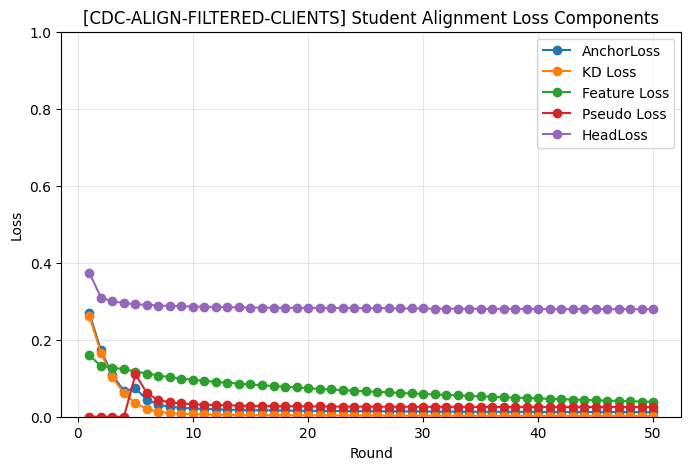

In [68]:
df = df_cdc_stage1.copy()

x_col = "round" if "round" in df.columns else None
x = df[x_col].values if x_col is not None else np.arange(1, len(df) + 1)

loss_items = {
    "AnchorLoss": ["anchor_loss", "AnchorLoss"],
    "KD Loss": ["anchor_kd_loss", "KD_loss", "kd_loss"],
    "Feature Loss": ["anchor_feat_loss", "feat_loss", "feature_loss"],
    "Pseudo Loss": ["anchor_pseudo_loss", "pseudo_loss"],
    "HeadLoss": ["head_loss", "HeadLoss"],
}

plt.figure(figsize=(8, 5))

plotted = False

for label, candidates in loss_items.items():
    col = _find_col(df, candidates)
    if col is not None:
        plt.plot(x, df[col].values, marker="o", label=label)
        plotted = True

if not plotted:
    print("No valid Stage 1 loss components found.")
    print("Available columns:", df.columns.tolist())
else:
    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.title(f"[{RUN_NAME_STAGE1}] Student Alignment Loss Components")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

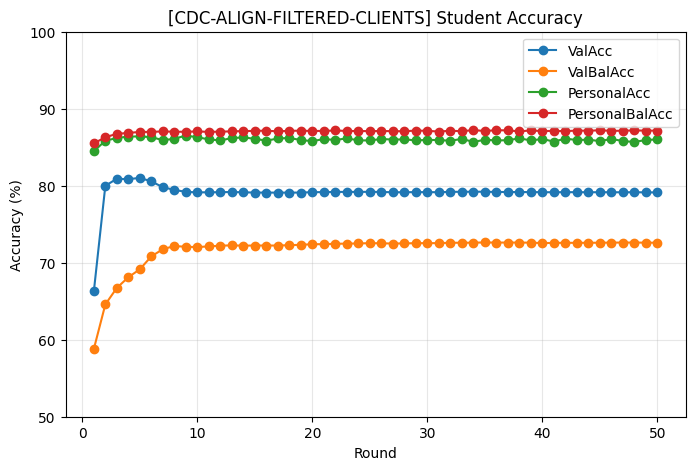

In [69]:
df = df_cdc_stage1.copy()

x_col = "round" if "round" in df.columns else None
x = df[x_col].values if x_col is not None else np.arange(1, len(df) + 1)

acc_items = {
    "ValAcc": ["val_acc", "ValAcc"],
    "ValBalAcc": ["val_bal_acc", "ValBalAcc"],
    "PersonalAcc": ["personal_acc", "PersonalAcc"],
    "PersonalBalAcc": ["personal_bal_acc", "PersonalBalAcc"],
}

plt.figure(figsize=(8, 5))

plotted = False

for label, candidates in acc_items.items():
    col = _find_col(df, candidates)
    if col is not None:
        plt.plot(x, df[col].values, marker="o", label=label)
        plotted = True

if not plotted:
    print("No valid Stage 1 accuracy metrics found.")
    print("Available columns:", df.columns.tolist())
else:
    plt.xlabel("Round")
    plt.ylabel("Accuracy (%)")
    plt.title(f"[{RUN_NAME_STAGE1}] Student Accuracy")
    plt.ylim(50, 100)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [70]:
# Lock Stage 1 result

result_stage1 = result_cdc_align_filtered
RUN_NAME_STAGE2 = "CDC-STAGE2-PLAIN"

print(result_stage1.keys())
print(result_stage1["final_test_metrics"])

dict_keys(['teachers', 'student_model', 'projector', 'personal_heads', 'best_round', 'best_score', 'best_student_sd', 'best_shared_sd', 'best_projector_sd', 'best_personal_heads', 'history', 'final_test_metrics', 'run_name', 'stage1_output_heterogeneity_summary', 'stage1_output_heterogeneity_detail'])
{'loss': 0.41159361433271074, 'acc': 79.17323662356775, 'bal_acc': 73.00231512809512, 'f1': 46.30395013212277, 'recall': 64.44737834779329, 'precision': 36.13196573966374, 'specificity': 81.55725190839695, 'auprc': 40.56208080125435, 'pred_pos_rate': 24.852832965415747, 'true_pos_rate': 13.93356459581625, 'tn': 26710, 'fp': 6040, 'fn': 1885, 'tp': 3417}


In [116]:
# Check saved CDC results

import os
from pathlib import Path

saved_files = [
    "CDC_STAGE1_FINAL.pt",
    "CDC_STAGE1_FINAL_LOCKED.pt",
    "CDC_STAGE2_PLAIN_V1.pt",
    "CDC_STAGE2_PLAIN_V2_QW.pt",
    "CDC_STAGE2_FHE_V1.pt",
    "CDC_STAGE2_FHE_V2_QW.pt",
    "CDC_STAGE2_FINAL_COMPARISON.csv",
]

print("Current working directory:", os.getcwd())
print("=" * 80)

for fname in saved_files:
    p = Path(fname)
    if p.exists():
        print(f"✅ Found: {fname} | size={p.stat().st_size / (1024**2):.2f} MB")
    else:
        print(f"❌ Missing: {fname}")

Current working directory: /Users/hedychou
✅ Found: CDC_STAGE1_FINAL.pt | size=2.59 MB
✅ Found: CDC_STAGE1_FINAL_LOCKED.pt | size=2.59 MB
✅ Found: CDC_STAGE2_PLAIN_V1.pt | size=0.20 MB
✅ Found: CDC_STAGE2_PLAIN_V2_QW.pt | size=0.20 MB
✅ Found: CDC_STAGE2_FHE_V1.pt | size=0.21 MB
✅ Found: CDC_STAGE2_FHE_V2_QW.pt | size=0.21 MB
✅ Found: CDC_STAGE2_FINAL_COMPARISON.csv | size=0.00 MB


In [34]:
# Stage 2 Utilities
# Shared-personal decoupled FL

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F


def _to_cpu_state_dict(sd):
    return {
        k: v.detach().cpu().clone()
        for k, v in sd.items()
    }


def get_backbone_state(model):
    return _to_cpu_state_dict(model.backbone.state_dict())


def load_backbone_state(model, backbone_sd, device):
    model.backbone.load_state_dict({
        k: v.to(device)
        for k, v in backbone_sd.items()
    })


def compute_backbone_delta(local_backbone_sd, global_backbone_sd):
    delta = {}
    for k in global_backbone_sd.keys():
        delta[k] = local_backbone_sd[k].cpu() - global_backbone_sd[k].cpu()
    return delta


def average_backbone_deltas(local_deltas, weights=None):
    if len(local_deltas) == 0:
        raise ValueError("No local deltas to average.")

    n = len(local_deltas)

    if weights is None:
        weights = np.ones(n, dtype=np.float64) / n
    else:
        weights = np.asarray(weights, dtype=np.float64)
        weights = weights / max(weights.sum(), 1e-12)

    avg_delta = {}

    for k in local_deltas[0].keys():
        avg_delta[k] = torch.zeros_like(local_deltas[0][k])

        for i in range(n):
            avg_delta[k] += float(weights[i]) * local_deltas[i][k]

    return avg_delta


def apply_backbone_delta(global_backbone_sd, avg_delta):
    new_sd = {}

    for k in global_backbone_sd.keys():
        new_sd[k] = global_backbone_sd[k].cpu() + avg_delta[k].cpu()

    return new_sd

In [35]:
# Build Stage 2 models from Stage 1

def build_stage2_global_model(stage1_result, num_classes=2, device="cpu"):
    global_model = StudentModelECG1D(num_classes=num_classes).to(device)

    # Prefer full student state if available
    if "best_student_sd" in stage1_result and stage1_result["best_student_sd"] is not None:
        global_model.load_state_dict({
            k: v.to(device)
            for k, v in stage1_result["best_student_sd"].items()
        })
    elif "student_model" in stage1_result and stage1_result["student_model"] is not None:
        global_model.load_state_dict(
            copy.deepcopy(stage1_result["student_model"].state_dict())
        )
    elif "best_shared_sd" in stage1_result and stage1_result["best_shared_sd"] is not None:
        global_model.backbone.load_state_dict({
            k: v.to(device)
            for k, v in stage1_result["best_shared_sd"].items()
        })
    else:
        raise ValueError("Cannot find Stage 1 student/backbone state.")

    return global_model


def build_stage2_client_models(
    stage1_result,
    num_clients,
    num_classes=2,
    device="cpu"
):
    global_model = build_stage2_global_model(
        stage1_result=stage1_result,
        num_classes=num_classes,
        device=device
    )

    client_models = []

    for cid in range(num_clients):
        model = StudentModelECG1D(num_classes=num_classes).to(device)
        model.load_state_dict(copy.deepcopy(global_model.state_dict()))

        # Load Stage 1 personalized head if available
        if (
            "best_personal_heads" in stage1_result
            and stage1_result["best_personal_heads"] is not None
            and cid < len(stage1_result["best_personal_heads"])
        ):
            model.head.load_state_dict({
                k: v.to(device)
                for k, v in stage1_result["best_personal_heads"][cid].items()
            })

        client_models.append(model)

    return global_model, client_models

In [36]:
# Stage 2 Local Training / Evaluation

def local_stage2_train(
    model,
    train_loader,
    val_loader,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    grad_clip=10.0,
):
    model.to(device)
    model.train()

    if class_weights is not None:
        ce_weight = class_weights.to(device)
    else:
        ce_weight = None

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    losses = []

    for _ in range(local_epochs):
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)
            loss = F.cross_entropy(logits, yb, weight=ce_weight)

            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)

            optimizer.step()

            losses.append(loss.item())

    train_loss = float(np.mean(losses)) if len(losses) > 0 else np.nan

    val_metrics = eval_model_binary(
        model=model,
        loader=val_loader,
        device=device,
        threshold=0.5
    )

    return {
        "train_loss": train_loss,
        "val_metrics": val_metrics,
    }


@torch.no_grad()
def eval_stage2_personal_models(client_models, client_val_loaders, device):
    y_true_all = []
    y_prob_all = []
    losses = []

    for cid, model in enumerate(client_models):
        model.eval()
        loader = client_val_loaders[cid]

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            prob = torch.softmax(logits, dim=1)[:, 1]

            losses.append(loss.item() * yb.size(0))
            y_true_all.extend(yb.detach().cpu().numpy().tolist())
            y_prob_all.extend(prob.detach().cpu().numpy().tolist())

    y_true = np.asarray(y_true_all)
    y_prob = np.asarray(y_prob_all)

    y_pred = (y_prob >= 0.5).astype(int)

    from sklearn.metrics import (
        accuracy_score,
        balanced_accuracy_score,
        f1_score,
        recall_score,
        average_precision_score,
    )

    acc = accuracy_score(y_true, y_pred) * 100
    bal_acc = balanced_accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, zero_division=0) * 100
    recall = recall_score(y_true, y_pred, zero_division=0) * 100
    auprc = average_precision_score(y_true, y_prob) * 100

    avg_loss = np.sum(losses) / max(len(y_true), 1)

    return {
        "loss": float(avg_loss),
        "acc": float(acc),
        "bal_acc": float(bal_acc),
        "f1": float(f1),
        "recall": float(recall),
        "auprc": float(auprc),
    }

In [37]:
# Quality-aware dynamic aggregation weights
# sample size + local validation performance

def compute_quality_weights(
    client_sample_sizes,
    client_val_metrics,
    sample_weight=0.5,
    quality_weight=0.5,
):
    sample_sizes = np.asarray(client_sample_sizes, dtype=np.float64)
    sample_norm = sample_sizes / max(sample_sizes.sum(), 1e-12)

    quality_scores = []

    for m in client_val_metrics:
        # Both are percentages
        q = 0.7 * m["bal_acc"] + 0.3 * m["auprc"]
        quality_scores.append(q)

    quality_scores = np.asarray(quality_scores, dtype=np.float64)

    # Avoid zero or negative weights
    quality_scores = np.maximum(quality_scores, 1e-6)
    quality_norm = quality_scores / max(quality_scores.sum(), 1e-12)

    weights = sample_weight * sample_norm + quality_weight * quality_norm
    weights = weights / max(weights.sum(), 1e-12)

    return weights

In [38]:
# Stage 2 Plain / Plain-QW Training

def stage2_train_plain(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    global_test_loader,
    stage1_result,
    num_rounds=10,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    num_classes=2,
    use_quality_weights=False,
    run_name="CDC-STAGE2-PLAIN",
):
    print("=" * 80)
    print(f"[{run_name}] Stage 2 training start")
    print("=" * 80)

    num_clients = len(client_loaders)

    global_model, client_models = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=num_clients,
        num_classes=num_classes,
        device=device
    )

    global_backbone = get_backbone_state(global_model)

    history = []

    best_score = -np.inf
    best_global_sd = None
    best_client_sds = None
    best_round = None

    for rnd in range(1, num_rounds + 1):
        print(f"\n[{run_name}] Round {rnd}/{num_rounds}")

        local_deltas = []
        local_train_losses = []
        local_val_metrics = []
        client_sample_sizes = []

        # Local update
        for cid in range(num_clients):
            # Sync shared backbone before local training
            load_backbone_state(client_models[cid], global_backbone, device)

            out = local_stage2_train(
                model=client_models[cid],
                train_loader=client_loaders[cid],
                val_loader=client_val_loaders[cid],
                local_epochs=local_epochs,
                lr=lr,
                device=device,
                class_weights=class_weights,
                grad_clip=10.0
            )

            local_train_losses.append(out["train_loss"])
            local_val_metrics.append(out["val_metrics"])

            client_sample_sizes.append(len(client_loaders[cid].dataset))

            local_backbone = get_backbone_state(client_models[cid])
            delta = compute_backbone_delta(local_backbone, global_backbone)
            local_deltas.append(delta)

        # Aggregation weights
        if use_quality_weights:
            weights = compute_quality_weights(
                client_sample_sizes=client_sample_sizes,
                client_val_metrics=local_val_metrics,
                sample_weight=0.5,
                quality_weight=0.5
            )
        else:
            weights = np.ones(num_clients, dtype=np.float64) / num_clients

        avg_delta = average_backbone_deltas(
            local_deltas=local_deltas,
            weights=weights
        )

        global_backbone = apply_backbone_delta(
            global_backbone_sd=global_backbone,
            avg_delta=avg_delta
        )

        # Sync global and client backbones after aggregation
        load_backbone_state(global_model, global_backbone, device)

        for cid in range(num_clients):
            load_backbone_state(client_models[cid], global_backbone, device)

        # Evaluation
        global_val_metrics = eval_model_binary(
            model=global_model,
            loader=global_val_loader,
            device=device,
            threshold=0.5
        )

        personal_metrics = eval_stage2_personal_models(
            client_models=client_models,
            client_val_loaders=client_val_loaders,
            device=device
        )

        mean_local_train_loss = float(np.nanmean(local_train_losses))

        row = {
            "round": rnd,
            "train_loss": mean_local_train_loss,

            "val_loss": global_val_metrics["loss"],
            "val_acc": global_val_metrics["acc"],
            "val_bal_acc": global_val_metrics["bal_acc"],
            "val_f1": global_val_metrics["f1"],
            "val_recall": global_val_metrics["recall"],
            "val_auprc": global_val_metrics["auprc"],

            "personal_loss": personal_metrics["loss"],
            "personal_acc": personal_metrics["acc"],
            "personal_bal_acc": personal_metrics["bal_acc"],
            "personal_f1": personal_metrics["f1"],
            "personal_recall": personal_metrics["recall"],
            "personal_auprc": personal_metrics["auprc"],

            "weights": weights.tolist(),
        }

        history.append(row)

        print(
            f"[{run_name}][Round {rnd}/{num_rounds}] "
            f"TrainLoss={mean_local_train_loss:.4f} | "
            f"ValAcc={global_val_metrics['acc']:.2f}% | "
            f"ValBalAcc={global_val_metrics['bal_acc']:.2f}% | "
            f"ValF1={global_val_metrics['f1']:.2f}% | "
            f"ValAUPRC={global_val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={personal_metrics['acc']:.2f}% | "
            f"PersonalBalAcc={personal_metrics['bal_acc']:.2f}% | "
            f"PersonalF1={personal_metrics['f1']:.2f}%"
        )

        # Best model selection
        score = (
            0.45 * global_val_metrics["bal_acc"]
            + 0.25 * global_val_metrics["auprc"]
            + 0.20 * personal_metrics["bal_acc"]
            + 0.10 * personal_metrics["f1"]
        )

        if score > best_score:
            best_score = score
            best_round = rnd

            best_global_sd = {
                k: v.detach().cpu().clone()
                for k, v in global_model.state_dict().items()
            }

            best_client_sds = [
                {
                    k: v.detach().cpu().clone()
                    for k, v in client_models[cid].state_dict().items()
                }
                for cid in range(num_clients)
            ]

    # Restore best states
    if best_global_sd is not None:
        global_model.load_state_dict({
            k: v.to(device)
            for k, v in best_global_sd.items()
        })

    if best_client_sds is not None:
        for cid in range(num_clients):
            client_models[cid].load_state_dict({
                k: v.to(device)
                for k, v in best_client_sds[cid].items()
            })

    final_test_metrics = eval_model_binary(
        model=global_model,
        loader=global_test_loader,
        device=device,
        threshold=0.5
    )

    print("\n" + "=" * 80)
    print(f"[{run_name}] Stage 2 completed.")
    print(f"Best round: {best_round} | Best score: {best_score:.4f}")
    print("Final global test metrics:")
    for k, v in final_test_metrics.items():
        if isinstance(v, (int, float)):
            print(f"{k}: {v:.4f}")
        else:
            print(k, v)
    print("=" * 80)

    result = {
        "global_model": global_model,
        "client_models": client_models,
        "history": history,
        "best_round": best_round,
        "best_score": best_score,
        "best_global_sd": best_global_sd,
        "best_client_sds": best_client_sds,
        "final_test_metrics": final_test_metrics,
        "run_name": run_name,
        "use_quality_weights": use_quality_weights,
    }

    return result

In [39]:
# Stage 2 Plain-v1: Equal-weight FedAvg backbone aggregation

result_stage2_plain = stage2_train_plain(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_stage1,

    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=class_weights,
    num_classes=2,

    use_quality_weights=False,
    run_name="CDC-STAGE2-PLAIN-V1"
)

torch.save(result_stage2_plain, "CDC_STAGE2_PLAIN_V1.pt")
print("Saved CDC_STAGE2_PLAIN_V1.pt")

[CDC-STAGE2-PLAIN-V1] Stage 2 training start

[CDC-STAGE2-PLAIN-V1] Round 1/50
[CDC-STAGE2-PLAIN-V1][Round 1/50] TrainLoss=0.3390 | ValAcc=79.15% | ValBalAcc=72.61% | ValF1=45.93% | ValAUPRC=42.00% | PersonalAcc=85.97% | PersonalBalAcc=87.19% | PersonalF1=63.32%

[CDC-STAGE2-PLAIN-V1] Round 2/50
[CDC-STAGE2-PLAIN-V1][Round 2/50] TrainLoss=0.3388 | ValAcc=79.20% | ValBalAcc=72.54% | ValF1=45.89% | ValAUPRC=42.03% | PersonalAcc=86.01% | PersonalBalAcc=87.18% | PersonalF1=63.36%

[CDC-STAGE2-PLAIN-V1] Round 3/50
[CDC-STAGE2-PLAIN-V1][Round 3/50] TrainLoss=0.3359 | ValAcc=79.23% | ValBalAcc=72.59% | ValF1=45.97% | ValAUPRC=42.05% | PersonalAcc=85.95% | PersonalBalAcc=87.11% | PersonalF1=63.25%

[CDC-STAGE2-PLAIN-V1] Round 4/50
[CDC-STAGE2-PLAIN-V1][Round 4/50] TrainLoss=0.3359 | ValAcc=79.28% | ValBalAcc=72.57% | ValF1=45.98% | ValAUPRC=42.08% | PersonalAcc=85.82% | PersonalBalAcc=87.16% | PersonalF1=63.11%

[CDC-STAGE2-PLAIN-V1] Round 5/50
[CDC-STAGE2-PLAIN-V1][Round 5/50] TrainLoss=0.334

In [41]:
# Stage 2 Plain-v2-QW: Quality-aware weighted backbone aggregation

result_stage2_plain_qw = stage2_train_plain(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_stage1,

    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=class_weights,
    num_classes=2,

    use_quality_weights=True,
    run_name="CDC-STAGE2-PLAIN-V2-QW"
)

torch.save(result_stage2_plain_qw, "CDC_STAGE2_PLAIN_V2_QW.pt")
print("Saved CDC_STAGE2_PLAIN_V2_QW.pt")

[CDC-STAGE2-PLAIN-V2-QW] Stage 2 training start

[CDC-STAGE2-PLAIN-V2-QW] Round 1/50
[CDC-STAGE2-PLAIN-V2-QW][Round 1/50] TrainLoss=0.3371 | ValAcc=79.19% | ValBalAcc=72.55% | ValF1=45.89% | ValAUPRC=42.00% | PersonalAcc=86.00% | PersonalBalAcc=87.25% | PersonalF1=63.39%

[CDC-STAGE2-PLAIN-V2-QW] Round 2/50
[CDC-STAGE2-PLAIN-V2-QW][Round 2/50] TrainLoss=0.3384 | ValAcc=79.25% | ValBalAcc=72.59% | ValF1=45.97% | ValAUPRC=42.04% | PersonalAcc=86.03% | PersonalBalAcc=87.20% | PersonalF1=63.41%

[CDC-STAGE2-PLAIN-V2-QW] Round 3/50
[CDC-STAGE2-PLAIN-V2-QW][Round 3/50] TrainLoss=0.3392 | ValAcc=79.28% | ValBalAcc=72.59% | ValF1=45.99% | ValAUPRC=42.06% | PersonalAcc=85.96% | PersonalBalAcc=87.21% | PersonalF1=63.32%

[CDC-STAGE2-PLAIN-V2-QW] Round 4/50
[CDC-STAGE2-PLAIN-V2-QW][Round 4/50] TrainLoss=0.3364 | ValAcc=79.36% | ValBalAcc=72.55% | ValF1=46.01% | ValAUPRC=42.10% | PersonalAcc=86.15% | PersonalBalAcc=87.26% | PersonalF1=63.60%

[CDC-STAGE2-PLAIN-V2-QW] Round 5/50
[CDC-STAGE2-PLAIN-V

In [42]:
# Load all saved CDC Stage 1 & Stage 2 results

import torch
from pathlib import Path
import pandas as pd
import numpy as np

def torch_load_compat(path, map_location="cpu"):
    """
    Compatible torch.load for different PyTorch versions.
    Only use this for files saved by yourself.
    """
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


try:
    _map_location = device
except NameError:
    _map_location = "cpu"


def load_result(filename, map_location=_map_location):
    p = Path(filename)
    if not p.exists():
        raise FileNotFoundError(
            f"❌ Missing file: {filename}\n"
            f"Current directory: {Path.cwd()}"
        )

    print(f"✅ Loading {filename}")
    return torch_load_compat(str(p), map_location=map_location)


# =========================
# Stage 1 result
# =========================

if Path("CDC_STAGE1_FINAL_LOCKED.pt").exists():
    result_stage1 = load_result("CDC_STAGE1_FINAL_LOCKED.pt")
    result_cdc_align_filtered = result_stage1
    print("✅ Stage 1 loaded from CDC_STAGE1_FINAL_LOCKED.pt")
elif Path("CDC_STAGE1_FINAL.pt").exists():
    result_stage1 = load_result("CDC_STAGE1_FINAL.pt")
    result_cdc_align_filtered = result_stage1
    print("✅ Stage 1 loaded from CDC_STAGE1_FINAL.pt")
else:
    raise FileNotFoundError(
        "❌ No Stage 1 saved result found. "
        "Expected CDC_STAGE1_FINAL_LOCKED.pt or CDC_STAGE1_FINAL.pt"
    )

RUN_NAME_STAGE1 = "CDC-ALIGN-FILTERED-CLIENTS"
RUN_NAME_STAGE2 = "CDC-STAGE2"


# =========================
# Stage 2 results
# =========================

result_stage2_plain = load_result("CDC_STAGE2_PLAIN_V1.pt")
result_stage2_plain_qw = load_result("CDC_STAGE2_PLAIN_V2_QW.pt")
result_stage2_fhe_v1 = load_result("CDC_STAGE2_FHE_V1.pt")
result_stage2_fhe_v2_qw = load_result("CDC_STAGE2_FHE_V2_QW.pt")


# =========================
# Pack Stage 2 results into dictionary
# =========================

results_stage2 = {
    "Plain-v1": result_stage2_plain,
    "Plain-v2-QW": result_stage2_plain_qw,
    "FHE-v1": result_stage2_fhe_v1,
    "FHE-v2-QW": result_stage2_fhe_v2_qw,
}


# =========================
# Quick check
# =========================

print("\n" + "=" * 80)
print("✅ All CDC Stage 1 & Stage 2 results loaded.")
print("=" * 80)

print("\n[Stage 1] final_test_metrics:")
print(result_stage1.get("final_test_metrics", "No final_test_metrics found."))

print("\n[Stage 2] loaded methods:")
for name, result in results_stage2.items():
    print(f"\n{name}")
    print("best_round =", result.get("best_round", "N/A"))
    print("final_test_metrics =", result.get("final_test_metrics", "N/A"))

✅ Loading CDC_STAGE1_FINAL_LOCKED.pt
✅ Stage 1 loaded from CDC_STAGE1_FINAL_LOCKED.pt
✅ Loading CDC_STAGE2_PLAIN_V1.pt
✅ Loading CDC_STAGE2_PLAIN_V2_QW.pt
✅ Loading CDC_STAGE2_FHE_V1.pt
✅ Loading CDC_STAGE2_FHE_V2_QW.pt

✅ All CDC Stage 1 & Stage 2 results loaded.

[Stage 1] final_test_metrics:
{'loss': 0.41159361433271074, 'acc': 79.17323662356775, 'bal_acc': 73.00231512809512, 'f1': 46.30395013212277, 'recall': 64.44737834779329, 'precision': 36.13196573966374, 'specificity': 81.55725190839695, 'auprc': 40.56208080125435, 'pred_pos_rate': 24.852832965415747, 'true_pos_rate': 13.93356459581625, 'tn': 26710, 'fp': 6040, 'fn': 1885, 'tp': 3417}

[Stage 2] loaded methods:

Plain-v1
best_round = 1
final_test_metrics = {'loss': 0.4116963263153466, 'acc': 79.19951645117209, 'bal_acc': 73.02548598973166, 'f1': 46.34262083926514, 'recall': 64.46623915503584, 'precision': 36.17314001481638, 'specificity': 81.58473282442749, 'auprc': 40.58154140247301, 'pred_pos_rate': 24.83180910333228, 'true_

In [43]:
hist_qw = pd.DataFrame(result_stage2_plain_qw["history"])

for r in [0, len(hist_qw) - 1]:
    print(f"\nRound {hist_qw.iloc[r]['round']} weights:")
    print(np.round(hist_qw.iloc[r]["weights"], 4))
    print("sum =", np.sum(hist_qw.iloc[r]["weights"]))


Round 1 weights:
[0.1358 0.0953 0.0392 0.0886 0.1264 0.1461 0.0537 0.1303 0.0542 0.0637
 0.0667]
sum = 1.0000000000000002

Round 50 weights:
[0.1361 0.0946 0.0393 0.0877 0.1266 0.1464 0.0539 0.1303 0.0538 0.064
 0.0672]
sum = 1.0


In [44]:
def extract_final_metrics(result, name):
    m = result["final_test_metrics"]
    return {
        "Setting": name,
        "Acc": m["acc"],
        "BalAcc": m["bal_acc"],
        "F1": m["f1"],
        "Recall": m["recall"],
        "Precision": m["precision"],
        "Specificity": m["specificity"],
        "AUPRC": m["auprc"],
        "PredPosRate": m["pred_pos_rate"],
    }

compare_stage2_df = pd.DataFrame([
    extract_final_metrics(result_stage2_plain, "Stage2-Plain-v1"),
    extract_final_metrics(result_stage2_plain_qw, "Stage2-Plain-v2-QW"),
])

compare_stage2_df

,Setting,Acc,BalAcc,F1,Recall,Precision,Specificity,AUPRC,PredPosRate
0,Stage2-Plain-v1,79.199516,73.025486,46.342621,64.466239,36.173140,81.584733,40.581541,24.831809
1,Stage2-Plain-v2-QW,79.388731,72.945721,46.394642,64.013580,36.381177,81.877863,40.675241,24.516451


In [45]:
hist_qw = pd.DataFrame(result_stage2_plain_qw["history"])

weight_round1 = np.array(hist_qw.iloc[0]["weights"])
weight_lastround = np.array(hist_qw.iloc[-1]["weights"])

weight_df = pd.DataFrame({
    "client_id": list(range(len(weight_round1))),
    "round_1_weight": weight_round1,
    "last_round_weight": weight_lastround,
    "delta": weight_lastround - weight_round1,
})

weight_df

,client_id,round_1_weight,last_round_weight,delta
0,0,0.135830,0.136130,0.000299
1,1,0.095262,0.094613,-0.000649
2,2,0.039153,0.039323,0.000170
3,3,0.088649,0.087660,-0.000990
4,4,0.126404,0.126618,0.000214
5,5,0.146061,0.146440,0.000379
6,6,0.053687,0.053911,0.000224
7,7,0.130341,0.130298,-0.000043
8,8,0.054229,0.053800,-0.000429
9,9,0.063731,0.064023,0.000292


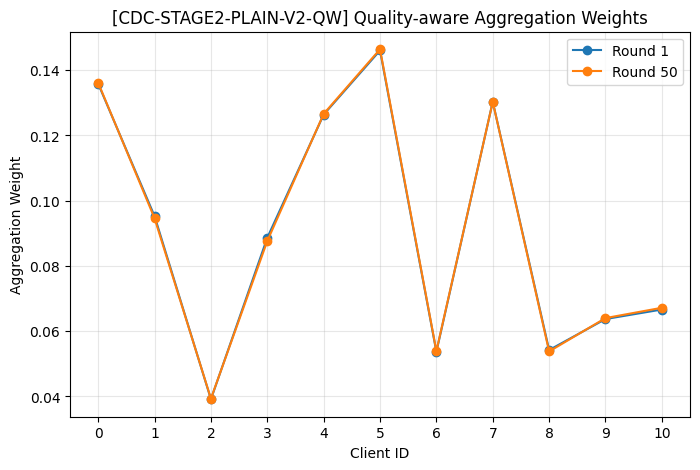

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
x = np.arange(len(weight_round1))

plt.plot(x, weight_round1, marker="o", label="Round 1")
plt.plot(x, weight_lastround, marker="o", label=f"Round {hist_qw.iloc[-1]['round']}")

plt.xlabel("Client ID")
plt.ylabel("Aggregation Weight")
plt.title("[CDC-STAGE2-PLAIN-V2-QW] Quality-aware Aggregation Weights")
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [47]:
try:
    import tenseal as ts
    print("TenSEAL imported successfully.")
except ImportError:
    raise ImportError(
        "TenSEAL is not installed. Please install it first, e.g. pip install tenseal"
    )

TenSEAL imported successfully.


In [48]:
# FHE Backend: CKKS via TenSEAL

class CKKSBackend:
    def __init__(
        self,
        poly_modulus_degree=8192,
        coeff_mod_bit_sizes=[60, 40, 40, 60],
        global_scale=2**40,
        chunk_size=2048,
    ):
        self.poly_modulus_degree = poly_modulus_degree
        self.coeff_mod_bit_sizes = coeff_mod_bit_sizes
        self.global_scale = global_scale
        self.chunk_size = chunk_size

        self.context = ts.context(
            ts.SCHEME_TYPE.CKKS,
            poly_modulus_degree=poly_modulus_degree,
            coeff_mod_bit_sizes=coeff_mod_bit_sizes,
        )
        self.context.global_scale = global_scale
        self.context.generate_galois_keys()

    def encrypt_vector(self, x):
        return ts.ckks_vector(self.context, x)

    def decrypt_vector(self, enc_x):
        return enc_x.decrypt()

In [49]:
he_backend = CKKSBackend(
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60],
    global_scale=2**40,
    chunk_size=2048,
)

print("CKKS backend ready.")

CKKS backend ready.


In [50]:
# Flatten / unflatten backbone state dict

def flatten_state_dict(sd):
    keys = []
    shapes = []
    arrays = []

    for k, v in sd.items():
        arr = v.detach().cpu().numpy().reshape(-1).astype(np.float64)
        keys.append(k)
        shapes.append(tuple(v.shape))
        arrays.append(arr)

    flat = np.concatenate(arrays, axis=0)
    return flat, keys, shapes


def unflatten_to_state_dict(flat, keys, shapes, reference_sd):
    new_sd = {}
    offset = 0

    for k, shape in zip(keys, shapes):
        size = int(np.prod(shape))
        part = flat[offset: offset + size].reshape(shape)
        offset += size

        dtype = reference_sd[k].dtype
        new_sd[k] = torch.tensor(part, dtype=dtype)

    return new_sd


def chunk_vector(x, chunk_size):
    return [
        x[i:i + chunk_size]
        for i in range(0, len(x), chunk_size)
    ]

In [51]:
# FHE encrypted averaging of backbone deltas

import time

def he_average_backbone_deltas(
    local_deltas,
    he_backend,
    weights=None,
    device="cpu",
):
    if len(local_deltas) == 0:
        raise ValueError("No local deltas to aggregate.")

    n = len(local_deltas)

    if weights is None:
        weights = np.ones(n, dtype=np.float64) / n
    else:
        weights = np.asarray(weights, dtype=np.float64)
        weights = weights / max(weights.sum(), 1e-12)

    # Use first delta as reference
    ref_delta = local_deltas[0]
    flat0, keys, shapes = flatten_state_dict(ref_delta)
    numel = len(flat0)

    flat_deltas = []
    for delta in local_deltas:
        flat, _, _ = flatten_state_dict(delta)
        flat_deltas.append(flat)

    chunk_size = he_backend.chunk_size
    num_chunks = int(np.ceil(numel / chunk_size))

    # =========================
    # Encrypt
    # =========================
    enc_start = time.time()

    encrypted_chunks_all = []

    for i in range(n):
        chunks = chunk_vector(flat_deltas[i], chunk_size)
        enc_chunks = [
            he_backend.encrypt_vector(chunk.tolist())
            for chunk in chunks
        ]
        encrypted_chunks_all.append(enc_chunks)

    enc_time = time.time() - enc_start

    # =========================
    # Aggregate in encrypted domain
    # =========================
    agg_start = time.time()

    agg_enc_chunks = []

    for cidx in range(num_chunks):
        agg_chunk = encrypted_chunks_all[0][cidx] * float(weights[0])

        for i in range(1, n):
            agg_chunk += encrypted_chunks_all[i][cidx] * float(weights[i])

        agg_enc_chunks.append(agg_chunk)

    agg_time = time.time() - agg_start

    # =========================
    # Decrypt
    # =========================
    dec_start = time.time()

    decrypted_chunks = [
        np.array(chunk.decrypt(), dtype=np.float64)
        for chunk in agg_enc_chunks
    ]

    avg_flat = np.concatenate(decrypted_chunks, axis=0)[:numel]

    dec_time = time.time() - dec_start

    avg_delta = unflatten_to_state_dict(
        flat=avg_flat,
        keys=keys,
        shapes=shapes,
        reference_sd=ref_delta,
    )

    # 保存 HE 统计信息，供 history 记录和后续画图使用
    he_stats = {
        "num_clients": int(n),
        "numel": int(numel),
        "num_chunks": int(num_chunks),
        "encrypt_time_sec": float(enc_time),
        "aggregate_time_sec": float(agg_time),
        "decrypt_time_sec": float(dec_time),

        # 通信开销 proxy
        # 每个 client 上传 num_chunks 个 CKKS ciphertext
        "upload_ciphertexts_per_round": int(n * num_chunks),
        # 聚合后服务器端保留 num_chunks 个聚合密文
        "aggregated_ciphertexts_per_round": int(num_chunks),
    }

    print(
        f"HE(numel={numel}, chunks={num_chunks}, "
        f"enc={enc_time:.6f}s, agg={agg_time:.6f}s, dec={dec_time:.6f}s)"
    )

    return avg_delta, he_stats

In [52]:
def stage2_train_fhe(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    global_test_loader,
    stage1_result,
    he_backend,
    num_rounds=10,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    num_classes=2,
    use_quality_weights=False,
    run_name="CDC-STAGE2-FHE-V1",
):
    print("=" * 80)
    print(f"[{run_name}] Stage 2 FHE training start")
    print("=" * 80)

    num_clients = len(client_loaders)

    global_model, client_models = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=num_clients,
        num_classes=num_classes,
        device=device
    )

    global_backbone = get_backbone_state(global_model)

    history = []

    best_score = -np.inf
    best_global_sd = None
    best_client_sds = None
    best_round = None

    for rnd in range(1, num_rounds + 1):
        print(f"\n[{run_name}] Round {rnd}/{num_rounds}")

        local_deltas = []
        local_train_losses = []
        local_val_metrics = []
        client_sample_sizes = []

        for cid in range(num_clients):
            load_backbone_state(client_models[cid], global_backbone, device)

            out = local_stage2_train(
                model=client_models[cid],
                train_loader=client_loaders[cid],
                val_loader=client_val_loaders[cid],
                local_epochs=local_epochs,
                lr=lr,
                device=device,
                class_weights=class_weights,
                grad_clip=10.0
            )

            local_train_losses.append(out["train_loss"])
            local_val_metrics.append(out["val_metrics"])
            client_sample_sizes.append(len(client_loaders[cid].dataset))

            local_backbone = get_backbone_state(client_models[cid])
            delta = compute_backbone_delta(local_backbone, global_backbone)
            local_deltas.append(delta)

        if use_quality_weights:
            weights = compute_quality_weights(
                client_sample_sizes=client_sample_sizes,
                client_val_metrics=local_val_metrics,
                sample_weight=0.5,
                quality_weight=0.5
            )
        else:
            weights = np.ones(num_clients, dtype=np.float64) / num_clients

        # FHE encrypted aggregation
        avg_delta, he_stats = he_average_backbone_deltas(
            local_deltas=local_deltas,
            he_backend=he_backend,
            weights=weights,
            device=device
        )

        global_backbone = apply_backbone_delta(
            global_backbone_sd=global_backbone,
            avg_delta=avg_delta
        )

        load_backbone_state(global_model, global_backbone, device)

        for cid in range(num_clients):
            load_backbone_state(client_models[cid], global_backbone, device)

        global_val_metrics = eval_model_binary(
            model=global_model,
            loader=global_val_loader,
            device=device,
            threshold=0.5
        )

        personal_metrics = eval_stage2_personal_models(
            client_models=client_models,
            client_val_loaders=client_val_loaders,
            device=device
        )

        mean_local_train_loss = float(np.nanmean(local_train_losses))

        row = {
            "round": rnd,
            "train_loss": mean_local_train_loss,

            "val_loss": global_val_metrics["loss"],
            "val_acc": global_val_metrics["acc"],
            "val_bal_acc": global_val_metrics["bal_acc"],
            "val_f1": global_val_metrics["f1"],
            "val_recall": global_val_metrics["recall"],
            "val_auprc": global_val_metrics["auprc"],

            "personal_loss": personal_metrics["loss"],
            "personal_acc": personal_metrics["acc"],
            "personal_bal_acc": personal_metrics["bal_acc"],
            "personal_f1": personal_metrics["f1"],
            "personal_recall": personal_metrics["recall"],
            "personal_auprc": personal_metrics["auprc"],

            "he_num_clients": he_stats["num_clients"],
            "he_numel": he_stats["numel"],
            "he_num_chunks": he_stats["num_chunks"],
            "he_encrypt_time_sec": he_stats["encrypt_time_sec"],
            "he_aggregate_time_sec": he_stats["aggregate_time_sec"],
            "he_decrypt_time_sec": he_stats["decrypt_time_sec"],

            "he_upload_ciphertexts_per_round": he_stats["upload_ciphertexts_per_round"],
            "he_aggregated_ciphertexts_per_round": he_stats["aggregated_ciphertexts_per_round"],

            "weights": weights.tolist(),
        }

        history.append(row)

        print(
            f"[{run_name}][Round {rnd}/{num_rounds}] "
            f"TrainLoss={mean_local_train_loss:.4f} | "
            f"ValAcc={global_val_metrics['acc']:.2f}% | "
            f"ValBalAcc={global_val_metrics['bal_acc']:.2f}% | "
            f"ValF1={global_val_metrics['f1']:.2f}% | "
            f"ValAUPRC={global_val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={personal_metrics['acc']:.2f}% | "
            f"PersonalBalAcc={personal_metrics['bal_acc']:.2f}% | "
            f"PersonalF1={personal_metrics['f1']:.2f}%"
        )

        score = (
            0.45 * global_val_metrics["bal_acc"]
            + 0.25 * global_val_metrics["auprc"]
            + 0.20 * personal_metrics["bal_acc"]
            + 0.10 * personal_metrics["f1"]
        )

        if score > best_score:
            best_score = score
            best_round = rnd

            best_global_sd = {
                k: v.detach().cpu().clone()
                for k, v in global_model.state_dict().items()
            }

            best_client_sds = [
                {
                    k: v.detach().cpu().clone()
                    for k, v in client_models[cid].state_dict().items()
                }
                for cid in range(num_clients)
            ]

    if best_global_sd is not None:
        global_model.load_state_dict({
            k: v.to(device)
            for k, v in best_global_sd.items()
        })

    if best_client_sds is not None:
        for cid in range(num_clients):
            client_models[cid].load_state_dict({
                k: v.to(device)
                for k, v in best_client_sds[cid].items()
            })

    final_test_metrics = eval_model_binary(
        model=global_model,
        loader=global_test_loader,
        device=device,
        threshold=0.5
    )

    print("\n" + "=" * 80)
    print(f"[{run_name}] Stage 2 FHE completed.")
    print(f"Best round: {best_round} | Best score: {best_score:.4f}")
    print("Final global test metrics:")
    for k, v in final_test_metrics.items():
        if isinstance(v, (int, float)):
            print(f"{k}: {v:.4f}")
        else:
            print(k, v)
    print("=" * 80)

    result = {
        "global_model": global_model,
        "client_models": client_models,
        "history": history,
        "best_round": best_round,
        "best_score": best_score,
        "best_global_sd": best_global_sd,
        "best_client_sds": best_client_sds,
        "final_test_metrics": final_test_metrics,
        "run_name": run_name,
        "use_quality_weights": use_quality_weights,
        "he_config": {
            "poly_modulus_degree": he_backend.poly_modulus_degree,
            "coeff_mod_bit_sizes": he_backend.coeff_mod_bit_sizes,
            "global_scale": he_backend.global_scale,
            "chunk_size": he_backend.chunk_size,
        }
    }

    return result

In [53]:
result_stage2_fhe_v1 = stage2_train_fhe(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_stage1,
    he_backend=he_backend,

    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=class_weights,
    num_classes=2,

    use_quality_weights=False,
    run_name="CDC-STAGE2-FHE-V1"
)

torch.save(result_stage2_fhe_v1, "CDC_STAGE2_FHE_V1.pt")
print("Saved CDC_STAGE2_FHE_V1.pt")

[CDC-STAGE2-FHE-V1] Stage 2 FHE training start

[CDC-STAGE2-FHE-V1] Round 1/50
HE(numel=1408, chunks=1, enc=0.022694s, agg=0.003932s, dec=0.000523s)
[CDC-STAGE2-FHE-V1][Round 1/50] TrainLoss=0.3382 | ValAcc=79.17% | ValBalAcc=72.59% | ValF1=45.92% | ValAUPRC=42.00% | PersonalAcc=85.90% | PersonalBalAcc=87.16% | PersonalF1=63.22%

[CDC-STAGE2-FHE-V1] Round 2/50
HE(numel=1408, chunks=1, enc=0.022188s, agg=0.003806s, dec=0.000424s)
[CDC-STAGE2-FHE-V1][Round 2/50] TrainLoss=0.3347 | ValAcc=79.21% | ValBalAcc=72.59% | ValF1=45.94% | ValAUPRC=42.03% | PersonalAcc=85.84% | PersonalBalAcc=87.17% | PersonalF1=63.13%

[CDC-STAGE2-FHE-V1] Round 3/50
HE(numel=1408, chunks=1, enc=0.022155s, agg=0.003850s, dec=0.000428s)
[CDC-STAGE2-FHE-V1][Round 3/50] TrainLoss=0.3371 | ValAcc=79.24% | ValBalAcc=72.66% | ValF1=46.04% | ValAUPRC=42.06% | PersonalAcc=85.80% | PersonalBalAcc=87.17% | PersonalF1=63.09%

[CDC-STAGE2-FHE-V1] Round 4/50
HE(numel=1408, chunks=1, enc=0.022117s, agg=0.003796s, dec=0.000430s)

In [54]:
result_stage2_fhe_v2_qw = stage2_train_fhe(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_stage1,
    he_backend=he_backend,

    num_rounds=50,          # 和 Plain-v2-QW 对齐
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=class_weights,
    num_classes=2,

    use_quality_weights=True,
    run_name="CDC-STAGE2-FHE-V2-QW"
)

torch.save(result_stage2_fhe_v2_qw, "CDC_STAGE2_FHE_V2_QW.pt")
print("Saved CDC_STAGE2_FHE_V2_QW.pt")

[CDC-STAGE2-FHE-V2-QW] Stage 2 FHE training start

[CDC-STAGE2-FHE-V2-QW] Round 1/50
HE(numel=1408, chunks=1, enc=0.022199s, agg=0.003809s, dec=0.000434s)
[CDC-STAGE2-FHE-V2-QW][Round 1/50] TrainLoss=0.3436 | ValAcc=79.14% | ValBalAcc=72.60% | ValF1=45.91% | ValAUPRC=42.00% | PersonalAcc=85.97% | PersonalBalAcc=87.12% | PersonalF1=63.27%

[CDC-STAGE2-FHE-V2-QW] Round 2/50
HE(numel=1408, chunks=1, enc=0.022054s, agg=0.003807s, dec=0.000439s)
[CDC-STAGE2-FHE-V2-QW][Round 2/50] TrainLoss=0.3368 | ValAcc=79.23% | ValBalAcc=72.63% | ValF1=46.00% | ValAUPRC=42.03% | PersonalAcc=85.86% | PersonalBalAcc=87.17% | PersonalF1=63.16%

[CDC-STAGE2-FHE-V2-QW] Round 3/50
HE(numel=1408, chunks=1, enc=0.022040s, agg=0.003781s, dec=0.000429s)
[CDC-STAGE2-FHE-V2-QW][Round 3/50] TrainLoss=0.3381 | ValAcc=79.26% | ValBalAcc=72.51% | ValF1=45.90% | ValAUPRC=42.06% | PersonalAcc=85.89% | PersonalBalAcc=87.20% | PersonalF1=63.22%

[CDC-STAGE2-FHE-V2-QW] Round 4/50
HE(numel=1408, chunks=1, enc=0.021997s, agg=0

In [38]:
print("FHE-v1 history columns:")
print(pd.DataFrame(result_stage2_fhe_v1["history"]).columns.tolist())

print("\nFHE-v2-QW history columns:")
print(pd.DataFrame(result_stage2_fhe_v2_qw["history"]).columns.tolist())

FHE-v1 history columns:
['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'personal_loss', 'personal_acc', 'personal_bal_acc', 'personal_f1', 'personal_recall', 'personal_auprc', 'he_num_clients', 'he_numel', 'he_num_chunks', 'he_encrypt_time_sec', 'he_aggregate_time_sec', 'he_decrypt_time_sec', 'he_upload_ciphertexts_per_round', 'he_aggregated_ciphertexts_per_round', 'weights']

FHE-v2-QW history columns:
['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'personal_loss', 'personal_acc', 'personal_bal_acc', 'personal_f1', 'personal_recall', 'personal_auprc', 'he_num_clients', 'he_numel', 'he_num_chunks', 'he_encrypt_time_sec', 'he_aggregate_time_sec', 'he_decrypt_time_sec', 'he_upload_ciphertexts_per_round', 'he_aggregated_ciphertexts_per_round', 'weights']


In [56]:
def extract_final_metrics(result, name):
    m = result["final_test_metrics"]
    return {
        "Setting": name,
        "Acc": m["acc"],
        "BalAcc": m["bal_acc"],
        "F1": m["f1"],
        "Recall": m["recall"],
        "Precision": m["precision"],
        "Specificity": m["specificity"],
        "AUPRC": m["auprc"],
        "PredPosRate": m["pred_pos_rate"],
    }

compare_all_stage2_df = pd.DataFrame([
    extract_final_metrics(result_stage2_plain, "Stage2-Plain-v1"),
    extract_final_metrics(result_stage2_plain_qw, "Stage2-Plain-v2-QW"),
    extract_final_metrics(result_stage2_fhe_v1, "Stage2-FHE-v1"),
    extract_final_metrics(result_stage2_fhe_v2_qw, "Stage2-FHE-v2-QW"),
])

compare_all_stage2_df

compare_all_stage2_df.to_csv("CDC_STAGE2_FINAL_COMPARISON.csv", index=False)
print("Saved CDC_STAGE2_FINAL_COMPARISON.csv")

Saved CDC_STAGE2_FINAL_COMPARISON.csv


In [57]:
# Lock Stage 2 results
results_stage2 = {
    "Plain-v1": result_stage2_plain,
    "Plain-v2-QW": result_stage2_plain_qw,
    "FHE-v1": result_stage2_fhe_v1,
    "FHE-v2-QW": result_stage2_fhe_v2_qw,
}

for name, result in results_stage2.items():
    print(name, "best_round =", result["best_round"])
    print(result["final_test_metrics"])
    print()

Plain-v1 best_round = 1
{'loss': 0.4116963263153466, 'acc': 79.19951645117209, 'bal_acc': 73.02548598973166, 'f1': 46.34262083926514, 'recall': 64.46623915503584, 'precision': 36.17314001481638, 'specificity': 81.58473282442749, 'auprc': 40.58154140247301, 'pred_pos_rate': 24.83180910333228, 'true_pos_rate': 13.93356459581625, 'tn': 26719, 'fp': 6031, 'fn': 1884, 'tp': 3418}

Plain-v2-QW best_round = 4
{'loss': 0.4105266428302042, 'acc': 79.38873120992326, 'bal_acc': 72.94572118831724, 'f1': 46.39464151459231, 'recall': 64.01357978121463, 'precision': 36.38117697502412, 'specificity': 81.87786259541984, 'auprc': 40.675240853528905, 'pred_pos_rate': 24.516451172080313, 'true_pos_rate': 13.93356459581625, 'tn': 26815, 'fp': 5935, 'fn': 1908, 'tp': 3394}

FHE-v1 best_round = 3
{'loss': 0.41144021244363854, 'acc': 79.27309996846421, 'bal_acc': 72.9971009067585, 'f1': 46.36518191091466, 'recall': 64.29649188985287, 'precision': 36.254386897798575, 'specificity': 81.69770992366412, 'auprc': 

In [75]:
# CDC CKKS vs Paillier Communication Micro-benchmark
# Same update parameters, real encryption

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from phe import paillier
    print("✅ phe imported")
except Exception:
    import sys
    import subprocess
    print("Installing phe ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "phe"])
    from phe import paillier
    print("✅ phe imported after installation")


def get_cdc_real_backbone_delta_vector(stage1_result, device="cpu"):
    """
    从 CDC Stage 2 中抽取一个真实 backbone delta。
    不是随机向量，而是用第一个 good client 训练 1 epoch 后得到的真实模型更新。
    """

    global_model, client_models = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=len(client_loaders_good),
        num_classes=NUM_CLASSES,
        device=device
    )

    global_backbone = get_backbone_state(global_model)

    cid = 0
    load_backbone_state(client_models[cid], global_backbone, device)

    out = local_stage2_train(
        model=client_models[cid],
        train_loader=client_loaders_good[cid],
        val_loader=client_val_loaders_good[cid],
        local_epochs=1,
        lr=5e-4,
        device=device,
        class_weights=class_weights,
        grad_clip=10.0
    )

    local_backbone = get_backbone_state(client_models[cid])
    delta = compute_backbone_delta(local_backbone, global_backbone)

    flat_delta, keys, shapes = flatten_state_dict(delta)
    flat_delta = flat_delta.astype(np.float64)

    print(f"✅ CDC real backbone delta extracted | numel={flat_delta.size}")

    return flat_delta


def benchmark_cdc_ckks_encrypt_vector(
    x,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60],
    global_scale=2**40,
    chunk_size=2048,
):
    """
    真实 CKKS 加密通信统计。
    使用当前 CDC notebook 里的 CKKSBackend。
    """

    backend = CKKSBackend(
        poly_modulus_degree=poly_modulus_degree,
        coeff_mod_bit_sizes=coeff_mod_bit_sizes,
        global_scale=global_scale,
        chunk_size=chunk_size,
    )

    chunks = chunk_vector(np.asarray(x, dtype=np.float64), chunk_size)

    enc_chunks = []
    ciphertext_bytes = 0

    t0 = time.time()

    for chunk in chunks:
        enc = backend.encrypt_vector(chunk.tolist())
        enc_chunks.append(enc)

        try:
            ciphertext_bytes += len(enc.serialize())
        except Exception:
            ciphertext_bytes += np.nan

    enc_time = time.time() - t0

    num_ciphertexts = len(enc_chunks)

    return {
        "scheme": "CKKS",
        "num_params": len(x),
        "num_ciphertexts": num_ciphertexts,
        "ciphertext_bytes": float(ciphertext_bytes),
        "ciphertext_mb": float(ciphertext_bytes / (1024 ** 2)),
        "encrypt_time_sec": float(enc_time),
        "bytes_per_param": float(ciphertext_bytes / max(len(x), 1)),
    }


def benchmark_cdc_paillier_encrypt_vector(
    x,
    key_length=1024,
    scale=1e6,
):
    """
    真实 Paillier 加密通信统计。
    Paillier 是逐标量加密，所以不要把 K 设置得太大。
    """

    public_key, private_key = paillier.generate_paillier_keypair(
        n_length=key_length
    )

    x_int = np.round(np.asarray(x, dtype=np.float64) * scale).astype(np.int64)

    ciphertext_bytes = 0
    enc_values = []

    t0 = time.time()

    for v in x_int:
        enc = public_key.encrypt(int(v))
        enc_values.append(enc)

        c = enc.ciphertext(be_secure=False)
        ciphertext_bytes += int((c.bit_length() + 7) // 8)

    enc_time = time.time() - t0

    return {
        "scheme": "Paillier",
        "num_params": len(x),
        "num_ciphertexts": len(x),
        "ciphertext_bytes": float(ciphertext_bytes),
        "ciphertext_mb": float(ciphertext_bytes / (1024 ** 2)),
        "encrypt_time_sec": float(enc_time),
        "bytes_per_param": float(ciphertext_bytes / max(len(x), 1)),
    }


def run_cdc_ckks_vs_paillier_micro_benchmark(
    flat_delta,
    k_list=None,
    paillier_key_length=1024,
    paillier_scale=1e6,
    ckks_chunk_size=2048,
):
    """
    对同一个真实 backbone delta 的前 K 个参数做 CKKS vs Paillier 对比。
    """

    if k_list is None:
        candidate_k = [64, 128, 256, 512, 1024, 2048, 4096, 8192]
        k_list = [k for k in candidate_k if k <= len(flat_delta)]

        # 如果 backbone 参数量本身比 8192 小，把完整长度也加进去
        if len(flat_delta) not in k_list:
            k_list.append(len(flat_delta))

    rows = []

    for k in k_list:
        x = flat_delta[:k]

        print(f"\nRunning CDC benchmark for K={k} parameters ...")

        ckks_row = benchmark_cdc_ckks_encrypt_vector(
            x,
            chunk_size=ckks_chunk_size,
        )
        rows.append(ckks_row)

        paillier_row = benchmark_cdc_paillier_encrypt_vector(
            x,
            key_length=paillier_key_length,
            scale=paillier_scale,
        )
        rows.append(paillier_row)

        print(
            f"K={k} | "
            f"CKKS={ckks_row['ciphertext_mb']:.4f}MB, "
            f"Paillier={paillier_row['ciphertext_mb']:.4f}MB | "
            f"CKKS time={ckks_row['encrypt_time_sec']:.4f}s, "
            f"Paillier time={paillier_row['encrypt_time_sec']:.4f}s"
        )

    df = pd.DataFrame(rows)

    df["plaintext_bytes_float32"] = df["num_params"] * 4
    df["expansion_ratio_vs_plain"] = (
        df["ciphertext_bytes"] / df["plaintext_bytes_float32"]
    )

    return df


# 1. 抽取一个 CDC 真实 Stage 2 backbone delta
cdc_flat_delta_for_benchmark = get_cdc_real_backbone_delta_vector(
    result_stage1,
    device=device,
)

# 2. 对相同参数做 CKKS vs Paillier 真实加密通信对比
cdc_encryption_comm_benchmark_df = run_cdc_ckks_vs_paillier_micro_benchmark(
    flat_delta=cdc_flat_delta_for_benchmark,
    k_list=None,
    paillier_key_length=1024,
    paillier_scale=1e6,
    ckks_chunk_size=2048,
)

display(cdc_encryption_comm_benchmark_df)

# 3. 保存结果，方便之后写论文/画图
cdc_encryption_comm_benchmark_df.to_csv(
    "CDC_CKKS_VS_PAILLIER_COMM_BENCHMARK.csv",
    index=False
)

print("Saved CDC_CKKS_VS_PAILLIER_COMM_BENCHMARK.csv")

✅ phe imported
✅ CDC real backbone delta extracted | numel=1408

Running CDC benchmark for K=64 parameters ...
K=64 | CKKS=0.3190MB, Paillier=0.0156MB | CKKS time=0.0037s, Paillier time=0.8388s

Running CDC benchmark for K=128 parameters ...
K=128 | CKKS=0.3189MB, Paillier=0.0312MB | CKKS time=0.0034s, Paillier time=1.6944s

Running CDC benchmark for K=256 parameters ...
K=256 | CKKS=0.3189MB, Paillier=0.0625MB | CKKS time=0.0034s, Paillier time=3.3381s

Running CDC benchmark for K=512 parameters ...
K=512 | CKKS=0.3189MB, Paillier=0.1250MB | CKKS time=0.0035s, Paillier time=6.6739s

Running CDC benchmark for K=1024 parameters ...
K=1024 | CKKS=0.3187MB, Paillier=0.2500MB | CKKS time=0.0032s, Paillier time=13.3982s

Running CDC benchmark for K=1408 parameters ...
K=1408 | CKKS=0.3189MB, Paillier=0.3437MB | CKKS time=0.0035s, Paillier time=18.3035s


,scheme,num_params,num_ciphertexts,ciphertext_bytes,ciphertext_mb,encrypt_time_sec,bytes_per_param,plaintext_bytes_float32,expansion_ratio_vs_plain
0,CKKS,64,1,334455.0,0.318961,0.003664,5225.859375,256,1306.464844
1,Paillier,64,64,16384.0,0.015625,0.838848,256.000000,256,64.000000
2,CKKS,128,1,334422.0,0.318930,0.003402,2612.671875,512,653.167969
3,Paillier,128,128,32767.0,0.031249,1.694390,255.992188,512,63.998047
4,CKKS,256,1,334415.0,0.318923,0.003448,1306.308594,1024,326.577148
5,Paillier,256,256,65533.0,0.062497,3.338105,255.988281,1024,63.997070
6,CKKS,512,1,334357.0,0.318868,0.003491,653.041016,2048,163.260254
7,Paillier,512,512,131070.0,0.124998,6.673946,255.996094,2048,63.999023
8,CKKS,1024,1,334129.0,0.318650,0.003219,326.297852,4096,81.574463
9,Paillier,1024,1024,262137.0,0.249993,13.398249,255.993164,4096,63.998291


Saved CDC_CKKS_VS_PAILLIER_COMM_BENCHMARK.csv


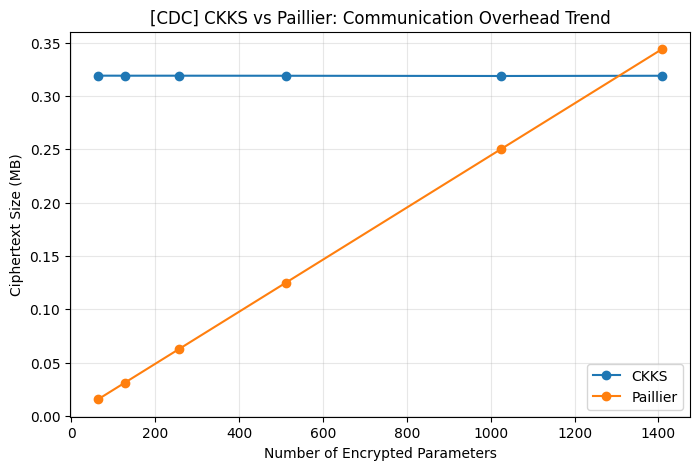

In [80]:
# Plot CDC CKKS vs Paillier Communication Trends

def plot_cdc_ckks_vs_paillier_trends(df):
    df = df.sort_values(["scheme", "num_params"]).copy()

    ckks_df = df[df["scheme"] == "CKKS"].sort_values("num_params")
    paillier_df = df[df["scheme"] == "Paillier"].sort_values("num_params")

    # 1. Communication overhead trend
    plt.figure(figsize=(8, 5))
    plt.plot(
        ckks_df["num_params"],
        ckks_df["ciphertext_mb"],
        marker="o",
        label="CKKS"
    )
    plt.plot(
        paillier_df["num_params"],
        paillier_df["ciphertext_mb"],
        marker="o",
        label="Paillier"
    )
    plt.xlabel("Number of Encrypted Parameters")
    plt.ylabel("Ciphertext Size (MB)")
    plt.title("[CDC] CKKS vs Paillier: Communication Overhead Trend")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
'''
    # 2. Expansion ratio trend
    plt.figure(figsize=(8, 5))
    plt.plot(
        ckks_df["num_params"],
        ckks_df["expansion_ratio_vs_plain"],
        marker="o",
        label="CKKS"
    )
    plt.plot(
        paillier_df["num_params"],
        paillier_df["expansion_ratio_vs_plain"],
        marker="o",
        label="Paillier"
    )
    plt.xlabel("Number of Encrypted Parameters")
    plt.ylabel("Ciphertext / Plaintext Ratio")
    plt.title("[CDC] CKKS vs Paillier: Expansion Ratio Trend")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # 3. Encryption time trend
    plt.figure(figsize=(8, 5))
    plt.plot(
        ckks_df["num_params"],
        ckks_df["encrypt_time_sec"],
        marker="o",
        label="CKKS"
    )
    plt.plot(
        paillier_df["num_params"],
        paillier_df["encrypt_time_sec"],
        marker="o",
        label="Paillier"
    )
    plt.xlabel("Number of Encrypted Parameters")
    plt.ylabel("Encryption Time (seconds)")
    plt.title("[CDC] CKKS vs Paillier: Encryption Time Trend")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

'''
plot_cdc_ckks_vs_paillier_trends(cdc_encryption_comm_benchmark_df)

In [77]:
# Extended CDC CKKS vs Paillier Scaling Benchmark
# 扩大参数维度，用于观察趋势

max_k = 4096

repeat_times = int(np.ceil(max_k / len(cdc_flat_delta_for_benchmark)))
cdc_flat_delta_extended = np.tile(cdc_flat_delta_for_benchmark, repeat_times)

print("Original CDC delta numel:", len(cdc_flat_delta_for_benchmark))
print("Extended delta numel:", len(cdc_flat_delta_extended))

cdc_encryption_comm_benchmark_df_extended = run_cdc_ckks_vs_paillier_micro_benchmark(
    flat_delta=cdc_flat_delta_extended,
    k_list=[64, 128, 256, 512, 1024, 2048, 4096],
    paillier_key_length=1024,
    paillier_scale=1e6,
    ckks_chunk_size=2048,
)

display(cdc_encryption_comm_benchmark_df_extended)

cdc_encryption_comm_benchmark_df_extended.to_csv(
    "CDC_CKKS_VS_PAILLIER_COMM_BENCHMARK_EXTENDED.csv",
    index=False
)

print("Saved CDC_CKKS_VS_PAILLIER_COMM_BENCHMARK_EXTENDED.csv")

Original CDC delta numel: 1408
Extended delta numel: 4224

Running CDC benchmark for K=64 parameters ...
K=64 | CKKS=0.3190MB, Paillier=0.0156MB | CKKS time=0.0041s, Paillier time=0.8536s

Running CDC benchmark for K=128 parameters ...
K=128 | CKKS=0.3187MB, Paillier=0.0312MB | CKKS time=0.0032s, Paillier time=1.7133s

Running CDC benchmark for K=256 parameters ...
K=256 | CKKS=0.3189MB, Paillier=0.0625MB | CKKS time=0.0037s, Paillier time=3.3827s

Running CDC benchmark for K=512 parameters ...
K=512 | CKKS=0.3190MB, Paillier=0.1250MB | CKKS time=0.0034s, Paillier time=6.7663s

Running CDC benchmark for K=1024 parameters ...
K=1024 | CKKS=0.3189MB, Paillier=0.2500MB | CKKS time=0.0034s, Paillier time=13.2291s

Running CDC benchmark for K=2048 parameters ...
K=2048 | CKKS=0.3189MB, Paillier=0.5000MB | CKKS time=0.0035s, Paillier time=26.6574s

Running CDC benchmark for K=4096 parameters ...
K=4096 | CKKS=0.6375MB, Paillier=0.9999MB | CKKS time=0.0065s, Paillier time=55.0031s


,scheme,num_params,num_ciphertexts,ciphertext_bytes,ciphertext_mb,encrypt_time_sec,bytes_per_param,plaintext_bytes_float32,expansion_ratio_vs_plain
0,CKKS,64,1,334458.0,0.318964,0.004116,5225.906250,256,1306.476562
1,Paillier,64,64,16380.0,0.015621,0.853607,255.937500,256,63.984375
2,CKKS,128,1,334193.0,0.318711,0.003240,2610.882812,512,652.720703
3,Paillier,128,128,32765.0,0.031247,1.713257,255.976562,512,63.994141
4,CKKS,256,1,334365.0,0.318875,0.003661,1306.113281,1024,326.528320
5,Paillier,256,256,65534.0,0.062498,3.382707,255.992188,1024,63.998047
6,CKKS,512,1,334463.0,0.318969,0.003437,653.248047,2048,163.312012
7,Paillier,512,512,131067.0,0.124995,6.766290,255.990234,2048,63.997559
8,CKKS,1024,1,334399.0,0.318908,0.003423,326.561523,4096,81.640381
9,Paillier,1024,1024,262127.0,0.249984,13.229054,255.983398,4096,63.995850


Saved CDC_CKKS_VS_PAILLIER_COMM_BENCHMARK_EXTENDED.csv


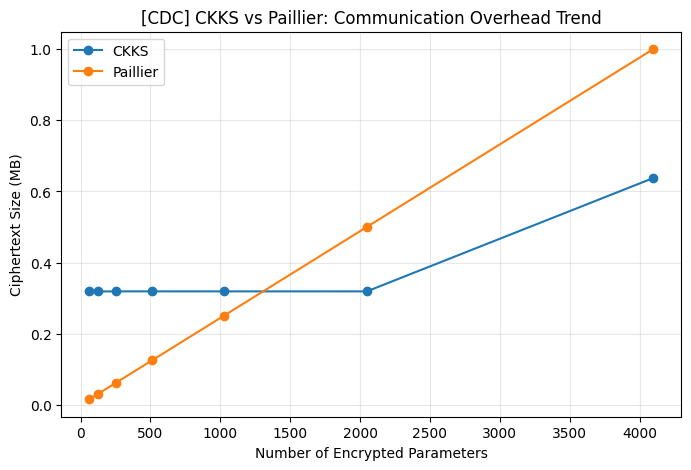

In [81]:
plot_cdc_ckks_vs_paillier_trends(
    cdc_encryption_comm_benchmark_df_extended
)

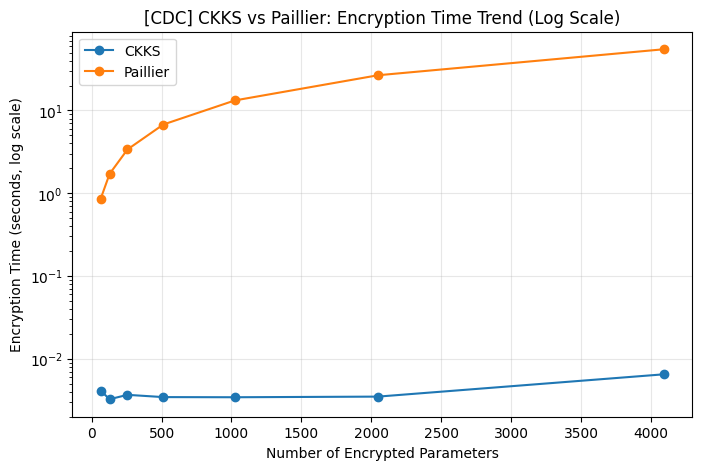

In [82]:
# CDC Encryption Time Trend - Log Scale

def plot_cdc_encryption_time_log(df):
    df = df.sort_values(["scheme", "num_params"]).copy()

    ckks_df = df[df["scheme"] == "CKKS"].sort_values("num_params")
    paillier_df = df[df["scheme"] == "Paillier"].sort_values("num_params")

    plt.figure(figsize=(8, 5))

    plt.plot(
        ckks_df["num_params"],
        ckks_df["encrypt_time_sec"],
        marker="o",
        label="CKKS"
    )

    plt.plot(
        paillier_df["num_params"],
        paillier_df["encrypt_time_sec"],
        marker="o",
        label="Paillier"
    )

    plt.yscale("log")
    plt.xlabel("Number of Encrypted Parameters")
    plt.ylabel("Encryption Time (seconds, log scale)")
    plt.title("[CDC] CKKS vs Paillier: Encryption Time Trend (Log Scale)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


plot_cdc_encryption_time_log(
    cdc_encryption_comm_benchmark_df_extended
)

,Method,Rounds,Avg Encrypt Time (s),Avg Aggregate Time (s),Avg Decrypt Time (s),Avg Total HE Time (s),Avg Num Clients,Avg Numel,Avg Num Chunks,Avg Upload Ciphertexts / Round,Avg Aggregated Ciphertexts / Round
0,FHE-v1,30,0.022567,0.003806,0.000434,0.026807,11.0,1408.0,1.0,11.0,1.0
1,FHE-v2-QW,30,0.022495,0.003803,0.000430,0.026728,11.0,1408.0,1.0,11.0,1.0


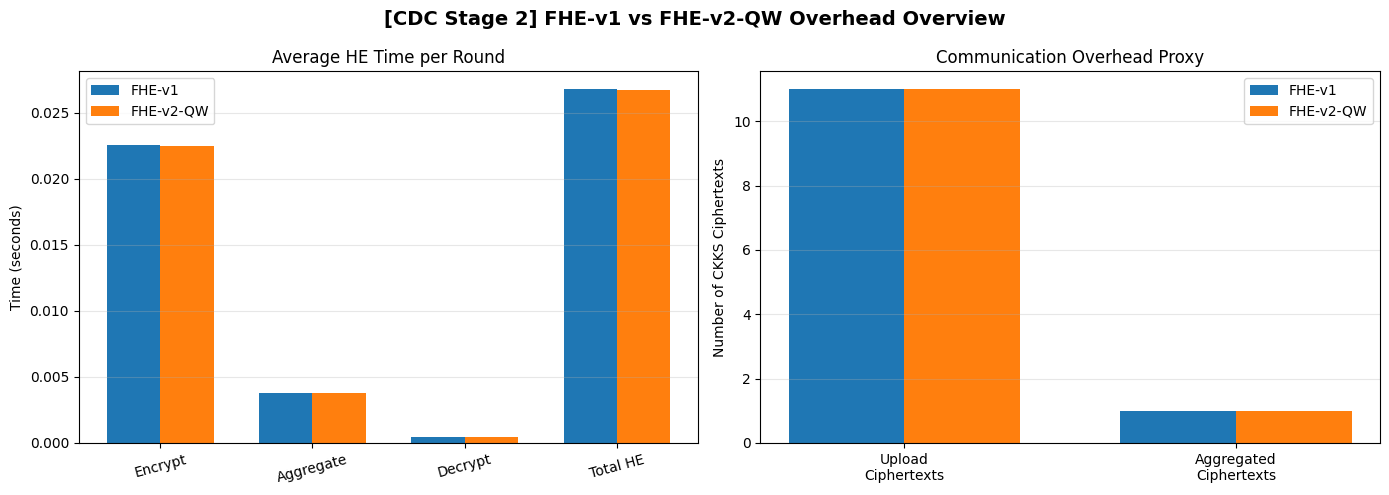

In [124]:
# CDC Stage 2 - FHE-v1 vs FHE-v2-QW Overhead Overview
# Same format as PTB

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def build_cdc_fhe_overview_df(result_dict):
    rows = []

    for method_name, result in result_dict.items():
        df = pd.DataFrame(result["history"]).copy()

        avg_enc = df["he_encrypt_time_sec"].mean()
        avg_agg = df["he_aggregate_time_sec"].mean()
        avg_dec = df["he_decrypt_time_sec"].mean()

        avg_total = (
            df["he_encrypt_time_sec"]
            + df["he_aggregate_time_sec"]
            + df["he_decrypt_time_sec"]
        ).mean()

        # Communication proxy
        if "he_upload_ciphertexts_per_round" in df.columns:
            avg_upload_ciphertexts = df["he_upload_ciphertexts_per_round"].mean()
        else:
            avg_upload_ciphertexts = (
                df["he_num_clients"] * df["he_num_chunks"]
            ).mean()

        if "he_aggregated_ciphertexts_per_round" in df.columns:
            avg_aggregated_ciphertexts = df["he_aggregated_ciphertexts_per_round"].mean()
        else:
            avg_aggregated_ciphertexts = df["he_num_chunks"].mean()

        rows.append({
            "Method": method_name,
            "Rounds": len(df),

            "Avg Encrypt Time (s)": avg_enc,
            "Avg Aggregate Time (s)": avg_agg,
            "Avg Decrypt Time (s)": avg_dec,
            "Avg Total HE Time (s)": avg_total,

            "Avg Num Clients": df["he_num_clients"].mean(),
            "Avg Numel": df["he_numel"].mean(),
            "Avg Num Chunks": df["he_num_chunks"].mean(),

            "Avg Upload Ciphertexts / Round": avg_upload_ciphertexts,
            "Avg Aggregated Ciphertexts / Round": avg_aggregated_ciphertexts,
        })

    return pd.DataFrame(rows)


def plot_cdc_fhe_one_overview(
    summary_df,
    title="[CDC Stage 2] FHE-v1 vs FHE-v2-QW Overhead Overview",
    save_path="CDC_FHE_V1_VS_V2_QW_OVERHEAD_OVERVIEW.png"
):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    width = 0.35

    v1 = summary_df[summary_df["Method"] == "FHE-v1"].iloc[0]
    v2 = summary_df[summary_df["Method"] == "FHE-v2-QW"].iloc[0]

    # =========================
    # Left: Average HE Time per Round
    # =========================
    time_metrics = [
        "Avg Encrypt Time (s)",
        "Avg Aggregate Time (s)",
        "Avg Decrypt Time (s)",
        "Avg Total HE Time (s)",
    ]

    x = np.arange(len(time_metrics))

    axes[0].bar(
        x - width / 2,
        [v1[m] for m in time_metrics],
        width=width,
        label="FHE-v1"
    )

    axes[0].bar(
        x + width / 2,
        [v2[m] for m in time_metrics],
        width=width,
        label="FHE-v2-QW"
    )

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(
        ["Encrypt", "Aggregate", "Decrypt", "Total HE"],
        rotation=15
    )

    axes[0].set_ylabel("Time (seconds)")
    axes[0].set_title("Average HE Time per Round")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)

    # =========================
    # Right: Communication Overhead Proxy
    # =========================
    comm_metrics = [
        "Avg Upload Ciphertexts / Round",
        "Avg Aggregated Ciphertexts / Round",
    ]

    x2 = np.arange(len(comm_metrics))

    axes[1].bar(
        x2 - width / 2,
        [v1[m] for m in comm_metrics],
        width=width,
        label="FHE-v1"
    )

    axes[1].bar(
        x2 + width / 2,
        [v2[m] for m in comm_metrics],
        width=width,
        label="FHE-v2-QW"
    )

    axes[1].set_xticks(x2)
    axes[1].set_xticklabels(
        ["Upload\nCiphertexts", "Aggregated\nCiphertexts"]
    )

    axes[1].set_ylabel("Number of CKKS Ciphertexts")
    axes[1].set_title("Communication Overhead Proxy")
    axes[1].legend()
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

   

cdc_fhe_compare_results = {
    "FHE-v1": result_stage2_fhe_v1,
    "FHE-v2-QW": result_stage2_fhe_v2_qw,
}

cdc_fhe_overview_df = build_cdc_fhe_overview_df(
    cdc_fhe_compare_results
)

display(cdc_fhe_overview_df)

cdc_fhe_overview_df.to_csv(
    "CDC_FHE_V1_VS_V2_QW_OVERHEAD_SUMMARY.csv",
    index=False
)

plot_cdc_fhe_one_overview(
    cdc_fhe_overview_df,
    title="[CDC Stage 2] FHE-v1 vs FHE-v2-QW Overhead Overview",
    save_path="CDC_FHE_V1_VS_V2_QW_OVERHEAD_OVERVIEW.png"
)

In [126]:
results_stage2 = {
    "Plain-v1": result_stage2_plain,
    "Plain-v2-QW": result_stage2_plain_qw,
    "FHE-v1": result_stage2_fhe_v1,
    "FHE-v2-QW": result_stage2_fhe_v2_qw,
}

In [66]:
# CDC Stage 2 metric plotting helpers

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def _find_metric_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

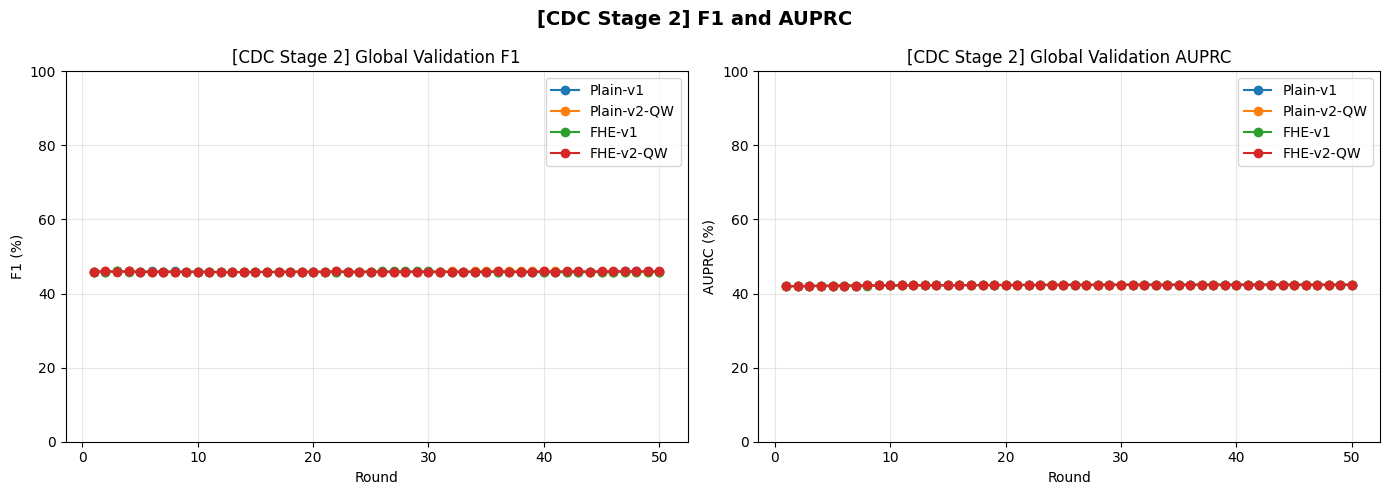

In [67]:
# CDC Stage 2 - Global Validation F1 and AUPRC

def plot_cdc_stage2_f1_auprc_together(
    results_dict,
    title_prefix="[CDC Stage 2]"
):
    metric_specs = [
        (["val_f1", "ValF1"], "Global Validation F1", "F1 (%)"),
        (["val_auprc", "ValAUPRC", "val_auprc_percent"], "Global Validation AUPRC", "AUPRC (%)"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{title_prefix} F1 and AUPRC", fontsize=14, fontweight="bold")

    for ax, (candidates, subtitle, ylabel) in zip(axes, metric_specs):
        plotted = False

        for name, result in results_dict.items():
            df = pd.DataFrame(result["history"])

            if "round" in df.columns:
                x = df["round"].values
            else:
                x = np.arange(1, len(df) + 1)

            metric_col = _find_metric_col(df, candidates)
            if metric_col is None:
                print(f"⚠️ {name}: metric not found from {candidates}")
                continue

            ax.plot(
                x,
                df[metric_col].values,
                marker="o",
                label=name
            )
            plotted = True

        ax.set_title(f"{title_prefix} {subtitle}")
        ax.set_xlabel("Round")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 100)
        ax.grid(alpha=0.3)

        if plotted:
            ax.legend()
        else:
            ax.text(
                0.5, 0.5,
                "Metric not found",
                ha="center",
                va="center",
                transform=ax.transAxes
            )

    plt.tight_layout()
    plt.show()


plot_cdc_stage2_f1_auprc_together(
    results_stage2,
    title_prefix="[CDC Stage 2]"
)

In [124]:
# FHE-DP-FedAvg and FHE-FedProx helpers
# For CDC + PneumoniaMNIST notebooks

import copy
import numpy as np
import torch
import torch.nn.functional as F


def backbone_delta_l2_norm(delta_sd):
    total = 0.0
    for v in delta_sd.values():
        total += torch.sum(v.detach().float().cpu() ** 2).item()
    return float(np.sqrt(total))


def clip_backbone_delta(delta_sd, max_norm=1.0):
    raw_norm = backbone_delta_l2_norm(delta_sd)
    clip_coef = min(1.0, max_norm / (raw_norm + 1e-12))

    clipped = {}
    for k, v in delta_sd.items():
        clipped[k] = v.detach().cpu() * clip_coef

    return clipped, raw_norm, clip_coef


def add_gaussian_noise_to_delta(avg_delta, noise_std):
    if noise_std is None or noise_std <= 0:
        return avg_delta

    noisy_delta = {}

    for k, v in avg_delta.items():
        noise = torch.normal(
            mean=0.0,
            std=float(noise_std),
            size=v.shape
        )
        noisy_delta[k] = v.detach().cpu() + noise

    return noisy_delta


def local_stage2_train_fedprox(
    model,
    train_loader,
    val_loader,
    global_backbone_sd,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    fedprox_mu=0.01,
    grad_clip=10.0,
):
    model.to(device)
    model.train()

    if class_weights is not None:
        ce_weight = class_weights.to(device)
    else:
        ce_weight = None

    # global backbone reference
    global_ref = {
        k: v.detach().to(device)
        for k, v in global_backbone_sd.items()
    }

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    losses = []

    for _ in range(local_epochs):
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(xb)
            ce_loss = F.cross_entropy(logits, yb, weight=ce_weight)

            prox_loss = 0.0
            for name, param in model.backbone.named_parameters():
                if name in global_ref:
                    prox_loss = prox_loss + torch.sum(
                        (param - global_ref[name]) ** 2
                    )

            loss = ce_loss + 0.5 * fedprox_mu * prox_loss
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=grad_clip
                )

            optimizer.step()
            losses.append(loss.item())

    train_loss = float(np.mean(losses)) if len(losses) > 0 else np.nan

    val_metrics = eval_model_binary(
        model=model,
        loader=val_loader,
        device=device,
        threshold=0.5
    )

    return {
        "train_loss": train_loss,
        "val_metrics": val_metrics,
    }

print("✅ DP/FedProx helper functions ready.")

✅ DP/FedProx helper functions ready.


In [125]:
# Unified FHE baselines:
# 1) FHE-DP-FedAvg
# 2) FHE-FedProx
# For CDC + PneumoniaMNIST notebooks

def stage2_train_fhe_baseline(
    client_loaders,
    client_val_loaders,
    global_val_loader,
    global_test_loader,
    stage1_result,
    he_backend,
    num_rounds=30,
    local_epochs=1,
    lr=5e-4,
    device="cpu",
    class_weights=None,
    num_classes=2,
    method="dp_fedavg",          # "dp_fedavg" or "fedprox"
    dp_clip_norm=1.0,
    dp_noise_multiplier=0.05,
    fedprox_mu=0.01,
    run_name="FHE-BASELINE",
):
    assert method in ["dp_fedavg", "fedprox"]

    print("=" * 80)
    print(f"[{run_name}] Stage 2 FHE baseline training start | method={method}")
    print("=" * 80)

    num_clients = len(client_loaders)

    global_model, client_models = build_stage2_client_models(
        stage1_result=stage1_result,
        num_clients=num_clients,
        num_classes=num_classes,
        device=device
    )

    global_backbone = get_backbone_state(global_model)

    history = []

    best_score = -np.inf
    best_round = None
    best_global_sd = None
    best_client_sds = None

    for rnd in range(1, num_rounds + 1):
        print(f"\n[{run_name}] Round {rnd}/{num_rounds}")

        local_deltas = []
        local_train_losses = []
        local_val_metrics = []
        client_sample_sizes = []

        raw_delta_norms = []
        clip_coefs = []

        for cid in range(num_clients):
            load_backbone_state(client_models[cid], global_backbone, device)

            if method == "fedprox":
                out = local_stage2_train_fedprox(
                    model=client_models[cid],
                    train_loader=client_loaders[cid],
                    val_loader=client_val_loaders[cid],
                    global_backbone_sd=global_backbone,
                    local_epochs=local_epochs,
                    lr=lr,
                    device=device,
                    class_weights=class_weights,
                    fedprox_mu=fedprox_mu,
                    grad_clip=10.0,
                )
            else:
                out = local_stage2_train(
                    model=client_models[cid],
                    train_loader=client_loaders[cid],
                    val_loader=client_val_loaders[cid],
                    local_epochs=local_epochs,
                    lr=lr,
                    device=device,
                    class_weights=class_weights,
                    grad_clip=10.0,
                )

            local_train_losses.append(out["train_loss"])
            local_val_metrics.append(out["val_metrics"])
            client_sample_sizes.append(len(client_loaders[cid].dataset))

            local_backbone = get_backbone_state(client_models[cid])
            delta = compute_backbone_delta(local_backbone, global_backbone)

            if method == "dp_fedavg":
                delta, raw_norm, clip_coef = clip_backbone_delta(
                    delta,
                    max_norm=dp_clip_norm
                )
                raw_delta_norms.append(raw_norm)
                clip_coefs.append(clip_coef)

            local_deltas.append(delta)

        # FedAvg baseline: uniform aggregation
        weights = np.ones(num_clients, dtype=np.float64) / num_clients

        # FHE encrypted aggregation
        avg_delta, he_stats = he_average_backbone_deltas(
            local_deltas=local_deltas,
            he_backend=he_backend,
            weights=weights,
            device=device
        )

        # DP noise is added to the aggregated clipped update
        # Approximate update-level DP baseline, not a formal accountant.
        if method == "dp_fedavg":
            dp_noise_std = float(dp_noise_multiplier * dp_clip_norm / num_clients)
            avg_delta = add_gaussian_noise_to_delta(
                avg_delta,
                noise_std=dp_noise_std
            )
        else:
            dp_noise_std = 0.0

        global_backbone = apply_backbone_delta(
            global_backbone_sd=global_backbone,
            avg_delta=avg_delta
        )

        load_backbone_state(global_model, global_backbone, device)

        for cid in range(num_clients):
            load_backbone_state(client_models[cid], global_backbone, device)

        global_val_metrics = eval_model_binary(
            model=global_model,
            loader=global_val_loader,
            device=device,
            threshold=0.5
        )

        personal_metrics = eval_stage2_personal_models(
            client_models=client_models,
            client_val_loaders=client_val_loaders,
            device=device
        )

        mean_local_train_loss = float(np.nanmean(local_train_losses))

        row = {
            "round": rnd,
            "train_loss": mean_local_train_loss,

            "val_loss": global_val_metrics["loss"],
            "val_acc": global_val_metrics["acc"],
            "val_bal_acc": global_val_metrics["bal_acc"],
            "val_f1": global_val_metrics["f1"],
            "val_recall": global_val_metrics["recall"],
            "val_auprc": global_val_metrics["auprc"],

            "personal_loss": personal_metrics["loss"],
            "personal_acc": personal_metrics["acc"],
            "personal_bal_acc": personal_metrics["bal_acc"],
            "personal_f1": personal_metrics["f1"],
            "personal_recall": personal_metrics["recall"],
            "personal_auprc": personal_metrics["auprc"],

            "method": method,

            "dp_clip_norm": float(dp_clip_norm) if method == "dp_fedavg" else None,
            "dp_noise_multiplier": float(dp_noise_multiplier) if method == "dp_fedavg" else None,
            "dp_noise_std": float(dp_noise_std) if method == "dp_fedavg" else None,
            "delta_norm_mean_preclip": float(np.mean(raw_delta_norms)) if raw_delta_norms else None,
            "clip_hit_rate": float(np.mean(np.array(clip_coefs) < 1.0)) if clip_coefs else None,

            "fedprox_mu": float(fedprox_mu) if method == "fedprox" else None,

            "he_num_clients": he_stats["num_clients"],
            "he_numel": he_stats["numel"],
            "he_num_chunks": he_stats["num_chunks"],
            "he_encrypt_time_sec": he_stats["encrypt_time_sec"],
            "he_aggregate_time_sec": he_stats["aggregate_time_sec"],
            "he_decrypt_time_sec": he_stats["decrypt_time_sec"],

            "weights": weights.tolist(),
        }

        # Some notebooks have these fields, some do not
        if "upload_ciphertexts_per_round" in he_stats:
            row["he_upload_ciphertexts_per_round"] = he_stats["upload_ciphertexts_per_round"]
        if "aggregated_ciphertexts_per_round" in he_stats:
            row["he_aggregated_ciphertexts_per_round"] = he_stats["aggregated_ciphertexts_per_round"]

        history.append(row)

        print(
            f"[{run_name}][Round {rnd}/{num_rounds}] "
            f"TrainLoss={mean_local_train_loss:.4f} | "
            f"ValAcc={global_val_metrics['acc']:.2f}% | "
            f"ValBalAcc={global_val_metrics['bal_acc']:.2f}% | "
            f"ValF1={global_val_metrics['f1']:.2f}% | "
            f"ValAUPRC={global_val_metrics['auprc']:.2f}% | "
            f"PersonalAcc={personal_metrics['acc']:.2f}% | "
            f"PersonalBalAcc={personal_metrics['bal_acc']:.2f}% | "
            f"HE(enc={he_stats['encrypt_time_sec']:.4f}s, "
            f"agg={he_stats['aggregate_time_sec']:.4f}s, "
            f"dec={he_stats['decrypt_time_sec']:.4f}s)"
        )

        score = (
            0.45 * global_val_metrics["bal_acc"]
            + 0.25 * global_val_metrics["auprc"]
            + 0.20 * personal_metrics["bal_acc"]
            + 0.10 * personal_metrics["f1"]
        )

        if score > best_score:
            best_score = score
            best_round = rnd

            best_global_sd = {
                k: v.detach().cpu().clone()
                for k, v in global_model.state_dict().items()
            }

            best_client_sds = [
                {
                    k: v.detach().cpu().clone()
                    for k, v in client_models[cid].state_dict().items()
                }
                for cid in range(num_clients)
            ]

    if best_global_sd is not None:
        global_model.load_state_dict({
            k: v.to(device)
            for k, v in best_global_sd.items()
        })

    if best_client_sds is not None:
        for cid in range(num_clients):
            client_models[cid].load_state_dict({
                k: v.to(device)
                for k, v in best_client_sds[cid].items()
            })

    final_test_metrics = eval_model_binary(
        model=global_model,
        loader=global_test_loader,
        device=device,
        threshold=0.5
    )

    print("\n" + "=" * 80)
    print(f"[{run_name}] Stage 2 FHE baseline completed.")
    print(f"Best round: {best_round} | Best score: {best_score:.4f}")
    print("Final global test metrics:")
    for k, v in final_test_metrics.items():
        if isinstance(v, (int, float)):
            print(f"{k}: {v:.4f}")
        else:
            print(k, v)
    print("=" * 80)

    result = {
        "global_model": global_model,
        "client_models": client_models,
        "history": history,
        "best_round": best_round,
        "best_score": best_score,
        "best_global_sd": best_global_sd,
        "best_client_sds": best_client_sds,
        "final_test_metrics": final_test_metrics,
        "run_name": run_name,
        "method": method,
        "he_config": {
            "poly_modulus_degree": he_backend.poly_modulus_degree,
            "coeff_mod_bit_sizes": he_backend.coeff_mod_bit_sizes,
            "global_scale": he_backend.global_scale,
            "chunk_size": he_backend.chunk_size,
        }
    }

    return result

print("✅ stage2_train_fhe_baseline ready.")

✅ stage2_train_fhe_baseline ready.


In [126]:
# CDC FHE-DP-FedAvg
result_cdc_stage2_fhe_dp_fedavg = stage2_train_fhe_baseline(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_cdc_align_filtered,
    he_backend=he_backend,
    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=class_weights,
    num_classes=NUM_CLASSES,
    method="dp_fedavg",
    dp_clip_norm=1.0,
    dp_noise_multiplier=0.05,
    run_name="CDC-STAGE2-FHE-DP-FEDAVG",
)

torch.save(
    result_cdc_stage2_fhe_dp_fedavg,
    "CDC_STAGE2_FHE_DP_FEDAVG.pt"
)


# CDC FHE-FedProx
result_cdc_stage2_fhe_fedprox = stage2_train_fhe_baseline(
    client_loaders=client_loaders_good,
    client_val_loaders=client_val_loaders_good,
    global_val_loader=global_val_loader,
    global_test_loader=global_test_loader,
    stage1_result=result_cdc_align_filtered,
    he_backend=he_backend,
    num_rounds=50,
    local_epochs=1,
    lr=5e-4,
    device=device,
    class_weights=class_weights,
    num_classes=NUM_CLASSES,
    method="fedprox",
    fedprox_mu=0.01,
    run_name="CDC-STAGE2-FHE-FEDPROX",
)

torch.save(
    result_cdc_stage2_fhe_fedprox,
    "CDC_STAGE2_FHE_FEDPROX.pt"
)

[CDC-STAGE2-FHE-DP-FEDAVG] Stage 2 FHE baseline training start | method=dp_fedavg

[CDC-STAGE2-FHE-DP-FEDAVG] Round 1/50
HE(numel=1408, chunks=1, enc=0.044919s, agg=0.007099s, dec=0.001005s)
[CDC-STAGE2-FHE-DP-FEDAVG][Round 1/50] TrainLoss=0.3375 | ValAcc=79.30% | ValBalAcc=72.66% | ValF1=46.07% | ValAUPRC=41.93% | PersonalAcc=86.01% | PersonalBalAcc=87.13% | HE(enc=0.0449s, agg=0.0071s, dec=0.0010s)

[CDC-STAGE2-FHE-DP-FEDAVG] Round 2/50
HE(numel=1408, chunks=1, enc=0.040322s, agg=0.006607s, dec=0.000754s)
[CDC-STAGE2-FHE-DP-FEDAVG][Round 2/50] TrainLoss=0.3356 | ValAcc=79.26% | ValBalAcc=72.53% | ValF1=45.93% | ValAUPRC=41.95% | PersonalAcc=85.83% | PersonalBalAcc=87.16% | HE(enc=0.0403s, agg=0.0066s, dec=0.0008s)

[CDC-STAGE2-FHE-DP-FEDAVG] Round 3/50
HE(numel=1408, chunks=1, enc=0.038313s, agg=0.006585s, dec=0.000741s)
[CDC-STAGE2-FHE-DP-FEDAVG][Round 3/50] TrainLoss=0.3397 | ValAcc=79.38% | ValBalAcc=72.52% | ValF1=45.99% | ValAUPRC=41.99% | PersonalAcc=85.84% | PersonalBalAcc=87.

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_metric(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def plot_one_stage2_metric(
    results_dict,
    metric_candidates,
    ylabel,
    title,
    ylim=None,
    suffix="",
    legend_loc="best"
):
    plt.figure(figsize=(8, 5))
    plotted = False

    for name, result in results_dict.items():
        df = pd.DataFrame(result["history"])

        if "round" in df.columns:
            x = df["round"].values
        else:
            x = np.arange(1, len(df) + 1)

        metric_col = _find_metric(df, metric_candidates)

        if metric_col is None:
            print(f"⚠️ {name} not found metric from {metric_candidates}")
            print("Available columns:", list(df.columns))
            continue

        y = df[metric_col].values

        # 不再给 QW 加星号
        label_name = name

        plt.plot(
            x,
            y,
            marker="o",
            label=f"{label_name}{suffix}"
        )

        plotted = True

    if not plotted:
        print("No valid metric found.")
        return

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("Round")
    plt.ylabel(ylabel)
    plt.title(title)

    legend = plt.legend(loc=legend_loc)

    # 只加粗 FHE-QW 的 legend 字体
    for text in legend.get_texts():
        if "FHE-QW" in text.get_text():
            text.set_fontweight("bold")

    plt.grid(alpha=0.3)
    plt.show()

def plot_one_stage2_personalized(
    results_dict,
    title,
    ylim=None,
    legend_loc="best"
):
    plt.figure(figsize=(8, 5))
    plotted = False

    for name, result in results_dict.items():
        df = pd.DataFrame(result["history"])

        if "round" in df.columns:
            x = df["round"].values
        else:
            x = np.arange(1, len(df) + 1)

        # 不再给 QW 加星号
        label_name = name

        acc_key = _find_metric(df, ["personal_acc", "PersonalAcc"])
        bal_key = _find_metric(df, ["personal_bal_acc", "PersonalBalAcc"])

        if acc_key is not None:
            plt.plot(
                x,
                df[acc_key].values,
                marker="o",
                label=f"{label_name} PersonalAcc"
            )
            plotted = True

        if bal_key is not None:
            plt.plot(
                x,
                df[bal_key].values,
                marker="s",
                linestyle="--",
                label=f"{label_name} PersonalBalAcc"
            )
            plotted = True

    if not plotted:
        print("No valid personalized metrics found.")
        return

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("Round")
    plt.ylabel("Accuracy (%)")
    plt.title(title)

    legend = plt.legend(loc=legend_loc)

    # 只加粗 FHE-QW 的 legend 字体
    for text in legend.get_texts():
        if "FHE-QW" in text.get_text():
            text.set_fontweight("bold")

    plt.grid(alpha=0.3)
    plt.show()

In [42]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def load_pt(path):
    print(f"Loading: {path}")
    obj = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    if isinstance(obj, dict) and "history" in obj:
        hist = obj["history"]
        print(f"✅ Loaded | history length={len(hist)} | last round={hist[-1].get('round', None)}")
    else:
        print("✅ Loaded")

    return obj


# ============================================================
# CDC Stage 2: load all six results
# ============================================================

result_cdc_stage2_plain_v1 = load_pt("./CDC_STAGE2_PLAIN_V1.pt")
result_cdc_stage2_plain_v2_qw = load_pt("./CDC_STAGE2_PLAIN_V2_QW.pt")

result_cdc_stage2_fhe_v1 = load_pt("./CDC_STAGE2_FHE_V1.pt")
result_cdc_stage2_fhe_v2_qw = load_pt("./CDC_STAGE2_FHE_V2_QW.pt")

result_cdc_stage2_fhe_dp_fedavg = load_pt("./CDC_STAGE2_FHE_DP_FEDAVG.pt")
result_cdc_stage2_fhe_fedprox = load_pt("./CDC_STAGE2_FHE_FEDPROX.pt")


# ============================================================
# Also create old-compatible aliases
# 防止旧代码里还在用这些名字
# ============================================================

stage2_plain_result = result_cdc_stage2_plain_v1
stage2_plain_v2_qw_result = result_cdc_stage2_plain_v2_qw

stage2_fhe_v1_result = result_cdc_stage2_fhe_v1
stage2_fhe_v2_qw_result = result_cdc_stage2_fhe_v2_qw

stage2_fhe_dp_fedavg_result = result_cdc_stage2_fhe_dp_fedavg
stage2_fhe_fedprox_result = result_cdc_stage2_fhe_fedprox


# 兼容你截图里这种变量名
result_stage2_plain_v1 = result_cdc_stage2_plain_v1
result_stage2_plain_v2_qw = result_cdc_stage2_plain_v2_qw

result_stage2_fhe_v1 = result_cdc_stage2_fhe_v1
result_stage2_fhe_v2_qw = result_cdc_stage2_fhe_v2_qw

result_stage2_fhe_dp_fedavg = result_cdc_stage2_fhe_dp_fedavg
result_stage2_fhe_fedprox = result_cdc_stage2_fhe_fedprox


print("\n✅ CDC Stage 2 variables loaded and aliases created.")

Loading: ./CDC_STAGE2_PLAIN_V1.pt
✅ Loaded | history length=50 | last round=50
Loading: ./CDC_STAGE2_PLAIN_V2_QW.pt
✅ Loaded | history length=50 | last round=50
Loading: ./CDC_STAGE2_FHE_V1.pt
✅ Loaded | history length=50 | last round=50
Loading: ./CDC_STAGE2_FHE_V2_QW.pt
✅ Loaded | history length=50 | last round=50
Loading: ./CDC_STAGE2_FHE_DP_FEDAVG.pt
✅ Loaded | history length=50 | last round=50
Loading: ./CDC_STAGE2_FHE_FEDPROX.pt
✅ Loaded | history length=50 | last round=50

✅ CDC Stage 2 variables loaded and aliases created.


In [43]:
cdc_results_to_check = {
    "Plain-v1": result_cdc_stage2_plain_v1,
    "Plain-v2-QW": result_cdc_stage2_plain_v2_qw,
    "FHE-FedAvg": result_cdc_stage2_fhe_v1,
    "FHE-v2-QW": result_cdc_stage2_fhe_v2_qw,
    "FHE-DP-FedAvg": result_cdc_stage2_fhe_dp_fedavg,
    "FHE-FedProx": result_cdc_stage2_fhe_fedprox,
}

for name, result in cdc_results_to_check.items():
    df = pd.DataFrame(result["history"])
    print(
        name,
        "| history length:", len(df),
        "| min round:", df["round"].min(),
        "| max round:", df["round"].max(),
        "| columns:", list(df.columns)[:10]
    )

Plain-v1 | history length: 50 | min round: 1 | max round: 50 | columns: ['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'personal_loss', 'personal_acc']
Plain-v2-QW | history length: 50 | min round: 1 | max round: 50 | columns: ['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'personal_loss', 'personal_acc']
FHE-FedAvg | history length: 50 | min round: 1 | max round: 50 | columns: ['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'personal_loss', 'personal_acc']
FHE-v2-QW | history length: 50 | min round: 1 | max round: 50 | columns: ['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'personal_loss', 'personal_acc']
FHE-DP-FedAvg | history length: 50 | min round: 1 | max round: 50 | columns: ['round', 'train_loss', 'val_loss', 'val_acc', 'val_bal_acc', 'val_f1', 'val_recall', 'val_auprc', 'p

In [44]:
results_stage2_cdc = {
    "Plain-v1": result_cdc_stage2_plain_v1,
    "Plain-v2-QW": result_cdc_stage2_plain_v2_qw,
    "FHE-FedAvg": result_cdc_stage2_fhe_v1,
    "FHE-DP-FedAvg": result_cdc_stage2_fhe_dp_fedavg,
    "FHE-FedProx": result_cdc_stage2_fhe_fedprox,
    "FHE-v2-QW": result_cdc_stage2_fhe_v2_qw,
}

group1_method_map = {
    "Plain-FedAvg": "Plain-v1",
    "Plain-QW": "Plain-v2-QW",
    "FHE-FedAvg": "FHE-FedAvg",
    "FHE-QW": "FHE-v2-QW",
}

group2_method_map = {
    "FHE-FedAvg": "FHE-FedAvg",
    "FHE-DP-FedAvg": "FHE-DP-FedAvg",
    "FHE-FedProx": "FHE-FedProx",
    "FHE-QW": "FHE-v2-QW",
}


def build_curve_group(results_dict, method_map):
    group = {}

    for display_name, key in method_map.items():
        if key in results_dict:
            group[display_name] = results_dict[key]
        else:
            print(f"⚠️ Missing method: {key}")

    return group


cdc_group1 = build_curve_group(results_stage2_cdc, group1_method_map)
cdc_group2 = build_curve_group(results_stage2_cdc, group2_method_map)

print("CDC Group 1:", list(cdc_group1.keys()))
print("CDC Group 2:", list(cdc_group2.keys()))

CDC Group 1: ['Plain-FedAvg', 'Plain-QW', 'FHE-FedAvg', 'FHE-QW']
CDC Group 2: ['FHE-FedAvg', 'FHE-DP-FedAvg', 'FHE-FedProx', 'FHE-QW']


In [45]:
group1_method_map = {
    "Plain-FedAvg": "Plain-v1",
    "Plain-QW": "Plain-v2-QW",
    "FHE-FedAvg": "FHE-FedAvg",
    "FHE-QW": "FHE-v2-QW",
}

group2_method_map = {
    "FHE-FedAvg": "FHE-FedAvg",
    "FHE-DP-FedAvg": "FHE-DP-FedAvg",
    "FHE-FedProx": "FHE-FedProx",
    "FHE-QW": "FHE-v2-QW",
}

cdc_group1 = build_curve_group(
    results_stage2_cdc,
    group1_method_map
)

cdc_group2 = build_curve_group(
    results_stage2_cdc,
    group2_method_map
)

print("CDC Group 1:", list(cdc_group1.keys()))
print("CDC Group 2:", list(cdc_group2.keys()))

CDC Group 1: ['Plain-FedAvg', 'Plain-QW', 'FHE-FedAvg', 'FHE-QW']
CDC Group 2: ['FHE-FedAvg', 'FHE-DP-FedAvg', 'FHE-FedProx', 'FHE-QW']


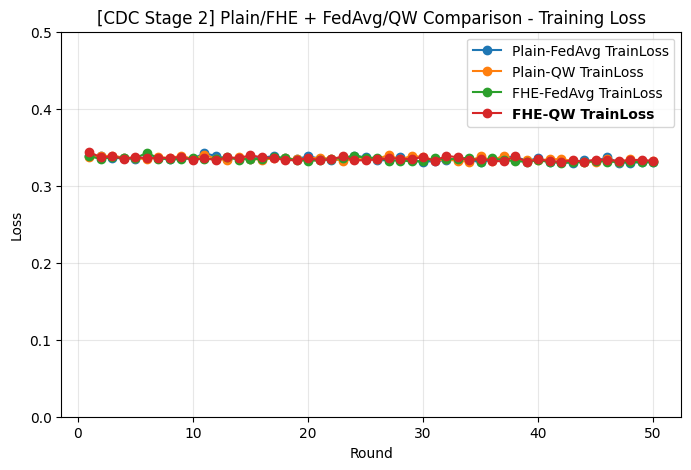

In [65]:
plot_one_stage2_metric(
    results_dict=cdc_group1,
    metric_candidates=["local_loss", "train_loss", "LocalLoss", "TrainLoss"],
    ylabel="Loss",
    title="[CDC Stage 2] Plain/FHE + FedAvg/QW Comparison - Training Loss",
    ylim=(0, 0.5),
    suffix=" TrainLoss",
    legend_loc="upper right"
)

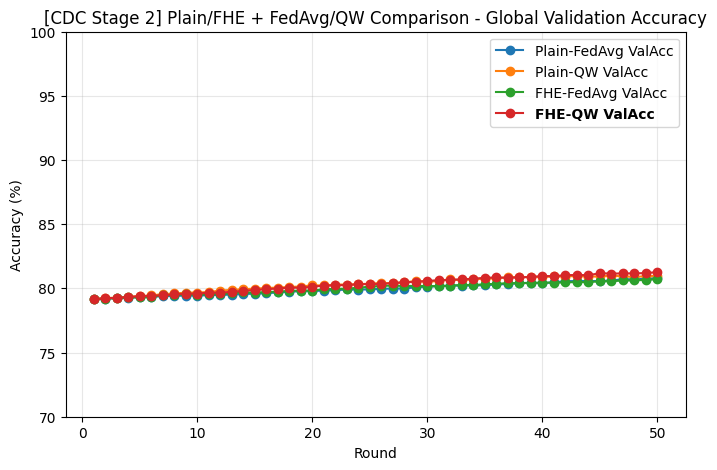

In [64]:
plot_one_stage2_metric(
    results_dict=cdc_group1,
    metric_candidates=["val_acc", "ValAcc"],
    ylabel="Accuracy (%)",
    title="[CDC Stage 2] Plain/FHE + FedAvg/QW Comparison - Global Validation Accuracy",
    ylim=(70, 100),
    suffix=" ValAcc",
    legend_loc="upper right"
)

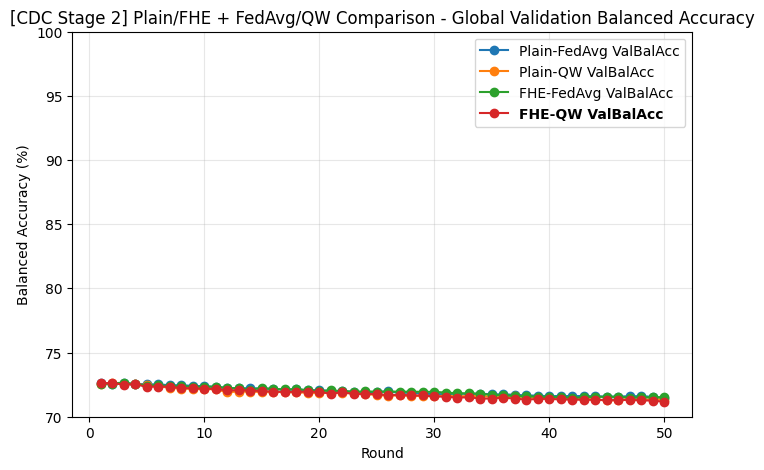

In [62]:
plot_one_stage2_metric(
    results_dict=cdc_group1,
    metric_candidates=["val_bal_acc", "ValBalAcc"],
    ylabel="Balanced Accuracy (%)",
    title="[CDC Stage 2] Plain/FHE + FedAvg/QW Comparison - Global Validation Balanced Accuracy",
    ylim=(70, 100),
    suffix=" ValBalAcc",
    legend_loc="upper right"
)

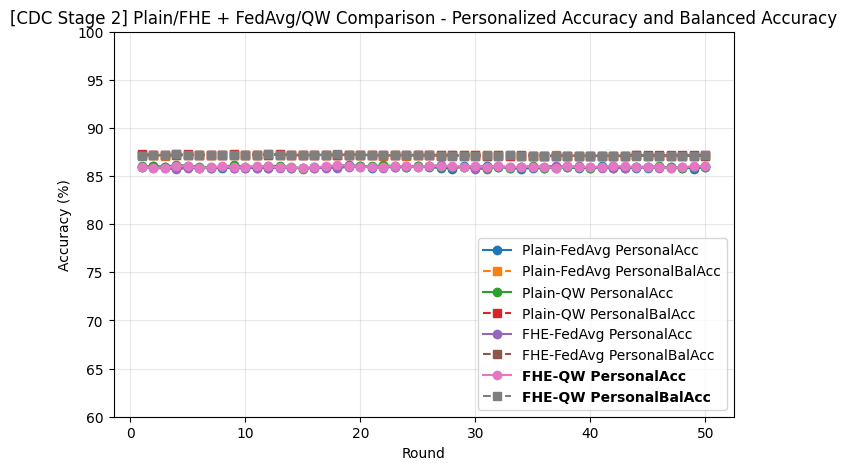

In [75]:
plot_one_stage2_personalized(
    results_dict=cdc_group1,
    title="[CDC Stage 2] Plain/FHE + FedAvg/QW Comparison - Personalized Accuracy and Balanced Accuracy",
    ylim=(60, 100),
    legend_loc="lower right"
)

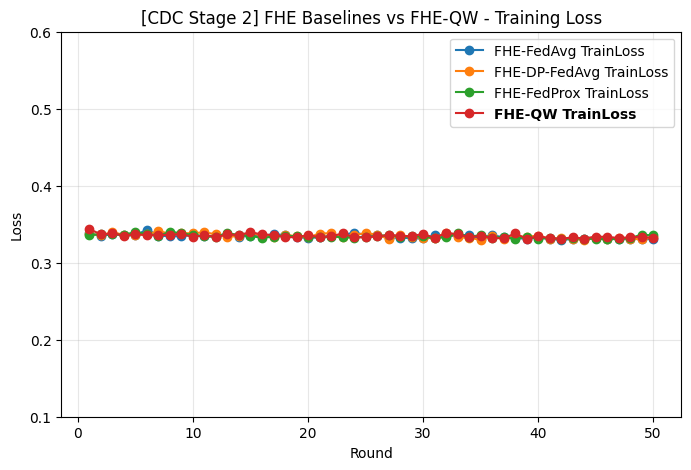

In [59]:
plot_one_stage2_metric(
    results_dict=cdc_group2,
    metric_candidates=["local_loss", "train_loss", "LocalLoss", "TrainLoss"],
    ylabel="Loss",
    title="[CDC Stage 2] FHE Baselines vs FHE-QW - Training Loss",
    ylim=(0.1, 0.6),
    suffix=" TrainLoss",
    legend_loc="upper right"
)

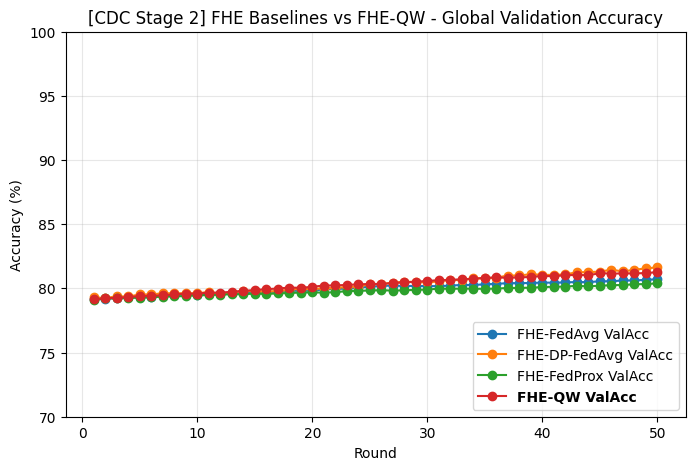

In [58]:
plot_one_stage2_metric(
    results_dict=cdc_group2,
    metric_candidates=["val_acc", "ValAcc"],
    ylabel="Accuracy (%)",
    title="[CDC Stage 2] FHE Baselines vs FHE-QW - Global Validation Accuracy",
    ylim=(70, 100),
    suffix=" ValAcc",
    legend_loc="lower right"
)

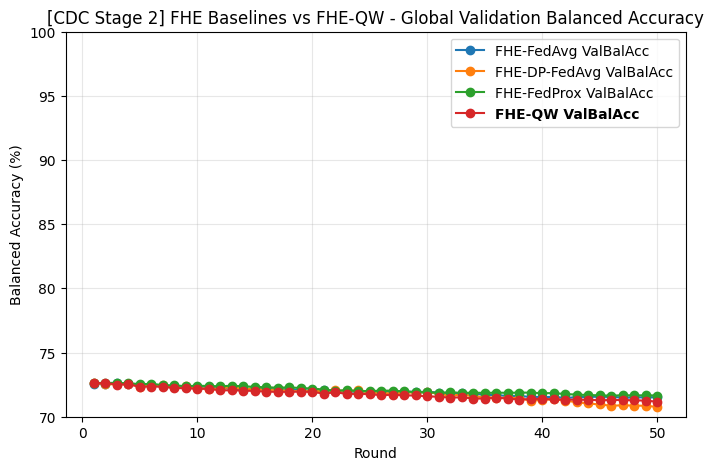

In [57]:
plot_one_stage2_metric(
    results_dict=cdc_group2,
    metric_candidates=["val_bal_acc", "ValBalAcc"],
    ylabel="Balanced Accuracy (%)",
    title="[CDC Stage 2] FHE Baselines vs FHE-QW - Global Validation Balanced Accuracy",
    ylim=(70, 100),
    suffix=" ValBalAcc",
    legend_loc="upper right"
)

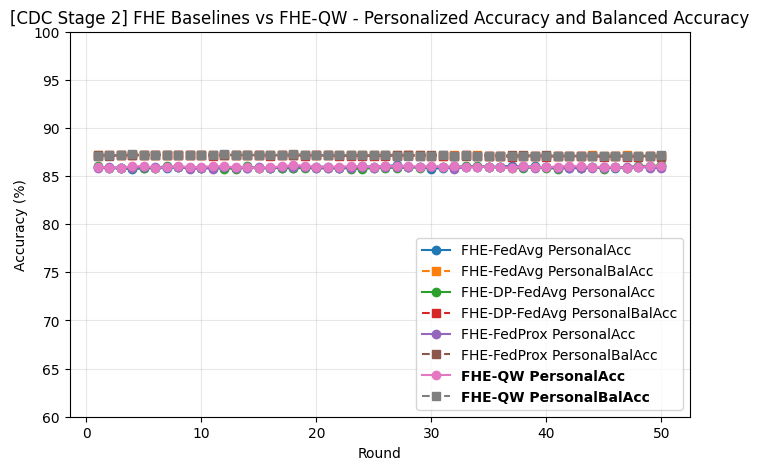

In [76]:
plot_one_stage2_personalized(
    results_dict=cdc_group2,
    title="[CDC Stage 2] FHE Baselines vs FHE-QW - Personalized Accuracy and Balanced Accuracy",
    ylim=(60, 100),
    legend_loc="lower right"
)